In [1]:
from google.colab import drive
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 20)

In [2]:
# Mounting My Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Research Projects /Data Science and ML /Code/WQI Calculation Code/New WQI Code for DSML/Output.csv")
df.head()

,WaterbodyName,Years,SampleDate,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Chloride,Conductivity @25°C,Dissolved Oxygen,ortho-Phosphate (as P) - unspecified,...,Total Hardness (as CaCO3),True Colour,IndWQI,IndWQI_Score,IWQI,IWQI_Score,DWQI,DWQI_Score,AWQI,AWQI_Score
0,ABBEYTOWN_010,2023,Feb,314.0,0.033,1.2,27.3,711.0,52.50,0.019,...,370.0,24.0,Poor,42.301154,Very Bad,17.448707,Poor,35.893750,Good,72.102564
1,Allua,2007,Aug,14.0,0.033,1.2,10.0,71.0,61.85,0.019,...,13.4,35.0,Good,78.931487,Average,55.420458,Medium,52.841607,Good,72.102564
2,Allua,2007,Aug,17.0,0.033,1.2,11.5,79.0,61.80,0.019,...,15.8,29.0,Good,78.214201,Bad,51.709486,Medium,52.518036,Good,72.102564
3,Allua,2007,Aug,18.0,0.033,1.2,11.3,78.0,62.40,0.019,...,15.9,31.0,Good,78.192201,Bad,52.073298,Medium,52.538929,Good,72.102564
4,Allua,2007,Sep,19.0,0.033,1.2,10.5,76.0,66.05,0.019,...,15.4,23.0,Good,78.295059,Bad,54.235504,Medium,52.630000,Good,72.102564


In [ ]:
df.shape

(29159, 22)

Initial Data Distribution Check

In [ ]:
df.describe()

,Years,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Chloride,Conductivity @25°C,Dissolved Oxygen,ortho-Phosphate (as P) - unspecified,pH,Temperature,Total Hardness (as CaCO3),True Colour,IndWQI_Score,IWQI_Score,DWQI_Score,AWQI_Score
count,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000,29159.000000
mean,2014.782537,139.858348,0.063573,1.276861,20.257858,363.039081,58.286184,0.068789,7.552057,10.850503,159.092110,58.137464,57.031176,22.309094,44.084146,82.788861
std,4.441425,95.554543,0.441630,0.559890,19.127637,182.190019,26.946092,1.010133,0.581265,5.179973,99.937379,52.913140,10.071092,10.674303,7.847075,49.276676
min,2007.000000,0.000000,0.000000,0.000000,0.000000,33.000000,0.000000,-0.004000,4.700000,0.600000,0.000000,0.000000,27.006154,0.000000,20.000000,49.666667
25%,2011.000000,55.000000,0.033000,1.200000,15.600000,229.000000,49.400000,0.017000,7.200000,8.200000,71.000000,25.000000,48.702234,16.378234,38.932143,68.769231
50%,2015.000000,127.000000,0.033000,1.200000,18.600000,356.000000,54.900000,0.019000,7.700000,10.700000,152.000000,45.000000,55.200916,17.983943,43.174107,72.102564
75%,2018.000000,214.000000,0.033000,1.200000,22.000000,501.000000,75.000000,0.022000,8.000000,13.100000,237.000000,74.000000,65.287967,22.265834,48.814286,76.397436
max,2023.000000,442.000000,40.000000,16.000000,1260.000000,4200.000000,198.000000,70.000000,9.800000,637.000000,642.000000,953.000000,84.193418,72.394068,91.307143,357.435897


Missing Value Check

In [ ]:
df.isnull().sum()

,0
WaterbodyName,0
Years,0
SampleDate,0
Alkalinity-total (as CaCO3),0
Ammonia-Total (as N),0
BOD - 5 days (Total),0
Chloride,0
Conductivity @25°C,0
Dissolved Oxygen,0
ortho-Phosphate (as P) - unspecified,0


Dataset Description and Dictionary


In [4]:
def create_data_dictionary(df):
    data_dict = []

    for col in df.columns:
        data_type = df[col].dtype
        non_null_count = df[col].count()
        null_count = df[col].isnull().sum()
        unique_count = df[col].nunique()

        # Get example values (first 3 unique values)
        example_values = df[col].dropna().unique()[:3]

        data_dict.append({
            "Feature Name": col,
            "Data Type": str(data_type),
            "Non-Null Count": non_null_count,
            "Null Count": null_count,
            "Unique Values": unique_count,
            "Example Values": example_values
        })

    return pd.DataFrame(data_dict)

# Usage
data_dictionary = create_data_dictionary(df)

# Display
print(data_dictionary)

# Optional: Save to CSV
data_dictionary.to_csv("data_dictionary.csv", index=False)

In [ ]:
num_features = df.select_dtypes(include=['number']).columns.tolist()
print(num_features)

['Years', 'Alkalinity-total (as CaCO3)', 'Ammonia-Total (as N)', 'BOD - 5 days (Total)', 'Chloride', 'Conductivity @25°C', 'Dissolved Oxygen', 'ortho-Phosphate (as P) - unspecified', 'pH', 'Temperature', 'Total Hardness (as CaCO3)', 'True Colour', 'IndWQI_Score', 'IWQI_Score', 'DWQI_Score', 'AWQI_Score']


In [6]:
num_features = ['Alkalinity-total (as CaCO3)', 'Ammonia-Total (as N)', 'BOD - 5 days (Total)', 'Chloride', 'Conductivity @25°C', 'Dissolved Oxygen', 'ortho-Phosphate (as P) - unspecified', 'pH', 'Temperature', 'Total Hardness (as CaCO3)', 'True Colour', 'IndWQI_Score', 'IWQI_Score', 'DWQI_Score', 'AWQI_Score']

In [7]:
# Rename columns
df = df.rename(columns={
    "Alkalinity-total (as CaCO3)": "Alkalinity",
    "Ammonia-Total (as N)": "Ammonia",
    "BOD - 5 days (Total)": "BOD",
    "Chloride": "Chloride",
    "Conductivity @25°C": "Conductivity",
    "Dissolved Oxygen": "DO",
    "ortho-Phosphate (as P) - unspecified": "Orthophosphate",
    "pH": "pH",
    "Temperature": "Temp",
    "Total Hardness (as CaCO3)": "Hardness",
    "True Colour": "Color"
})

In [8]:
num_features = [
    "Alkalinity", "Ammonia", "BOD", "Chloride",
    "Conductivity", "DO", "Orthophosphate",
    "pH", "Temp", "Hardness", "Color", 'IndWQI_Score', 'IWQI_Score', 'DWQI_Score', 'AWQI_Score'
]

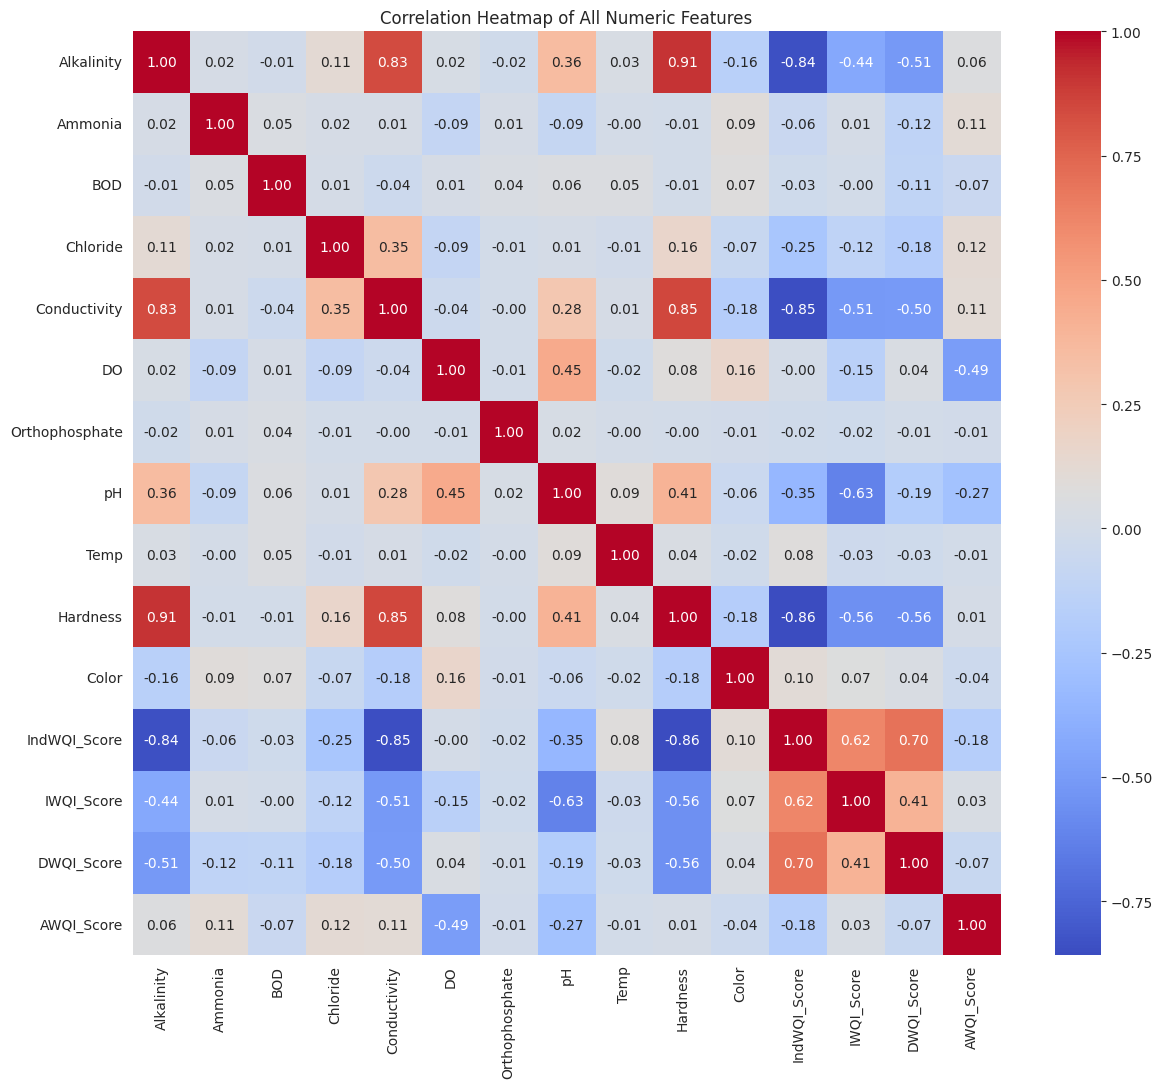

In [9]:
plt.figure(figsize=(14,12))
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of All Numeric Features")
plt.show()

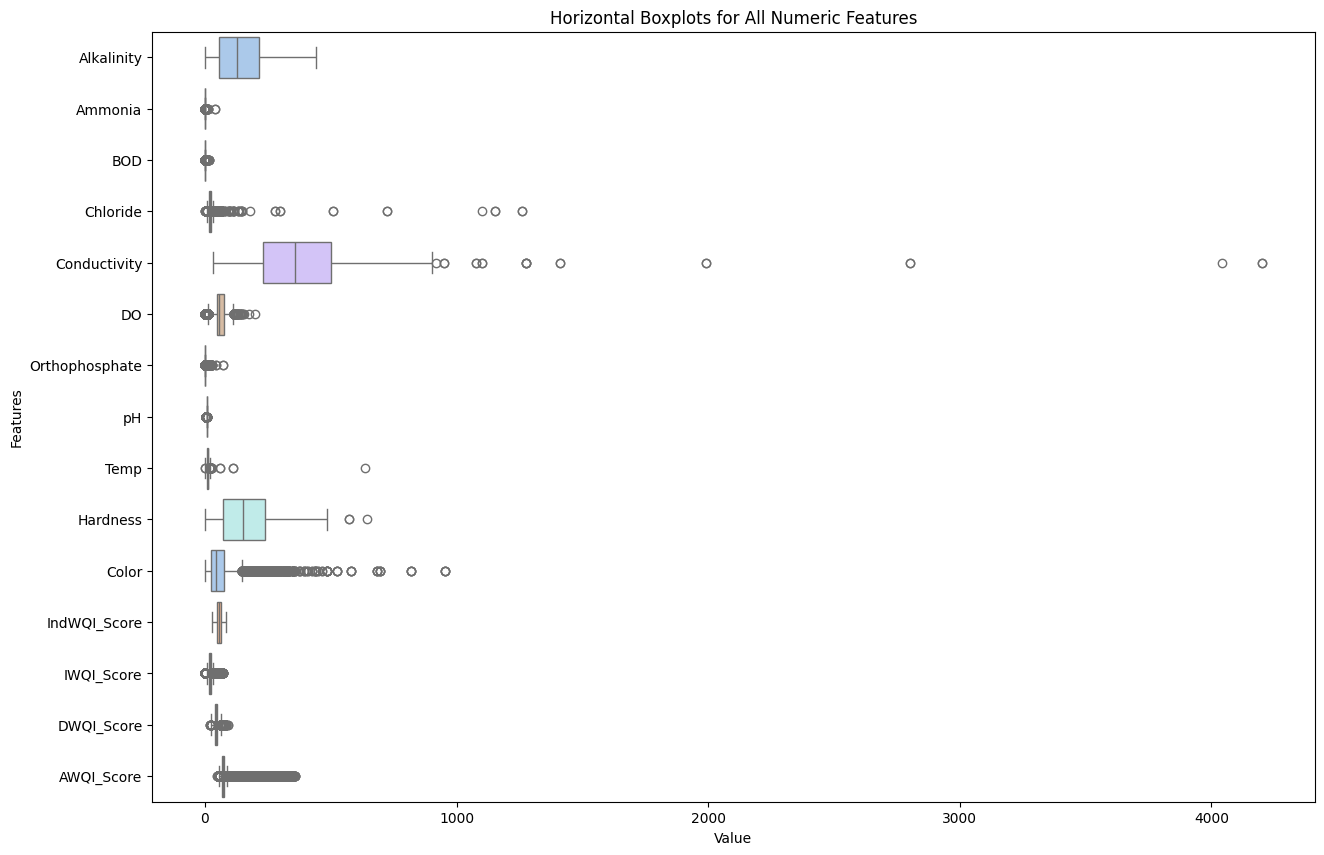

In [ ]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[num_features], orient="h", palette="pastel")
plt.title("Horizontal Boxplots for All Numeric Features")
plt.xlabel("Value")
plt.ylabel("Features")
plt.show()

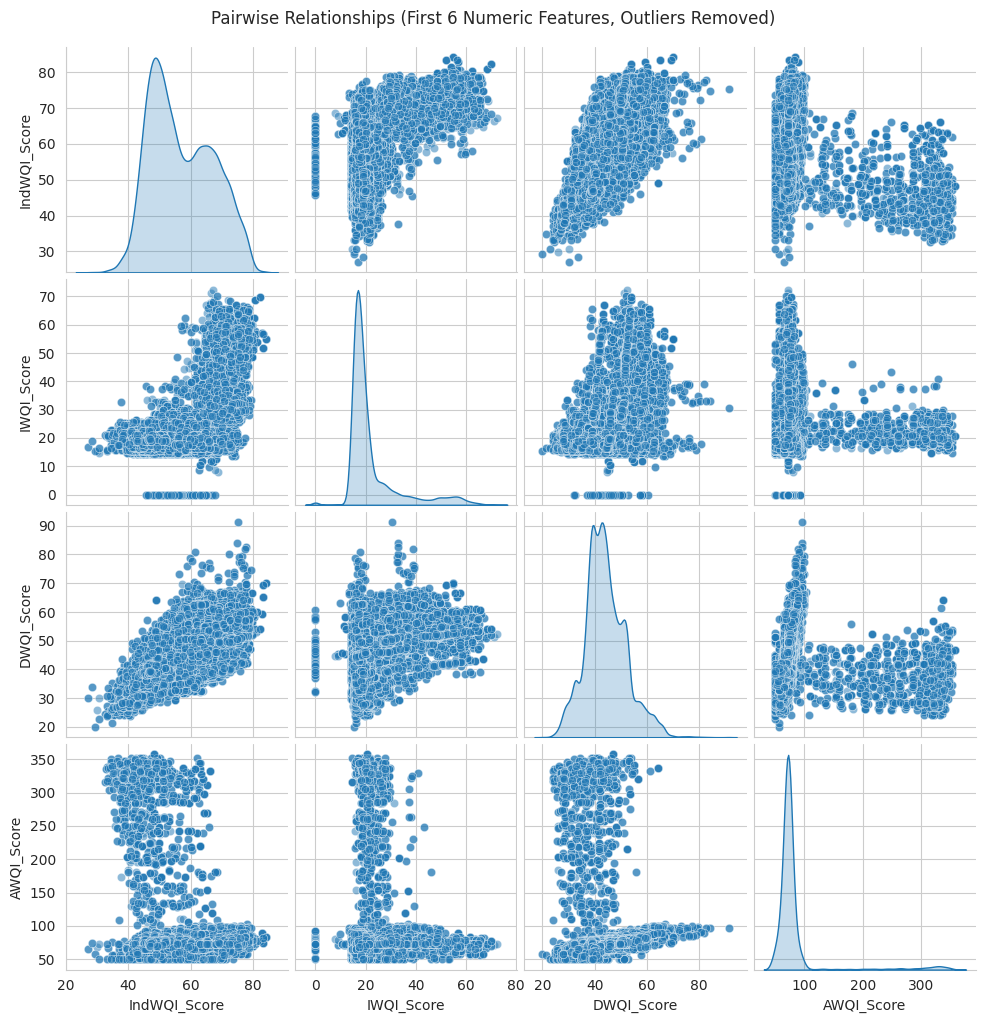

In [12]:
# Select the last 6 numeric features for initial code working check, as this code will take much execution time
pair_features = num_features[11:]

# Pairplot with KDE on diagonals and alpha for transparency
sns.pairplot(df[pair_features], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Pairwise Relationships (First 6 Numeric Features, Outliers Removed)", y=1.02)
plt.show()

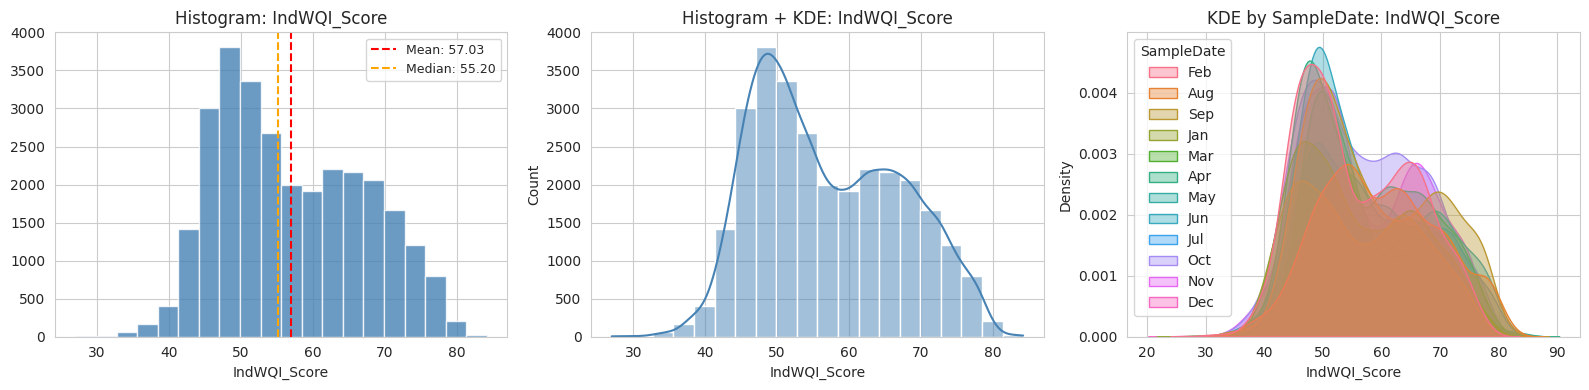

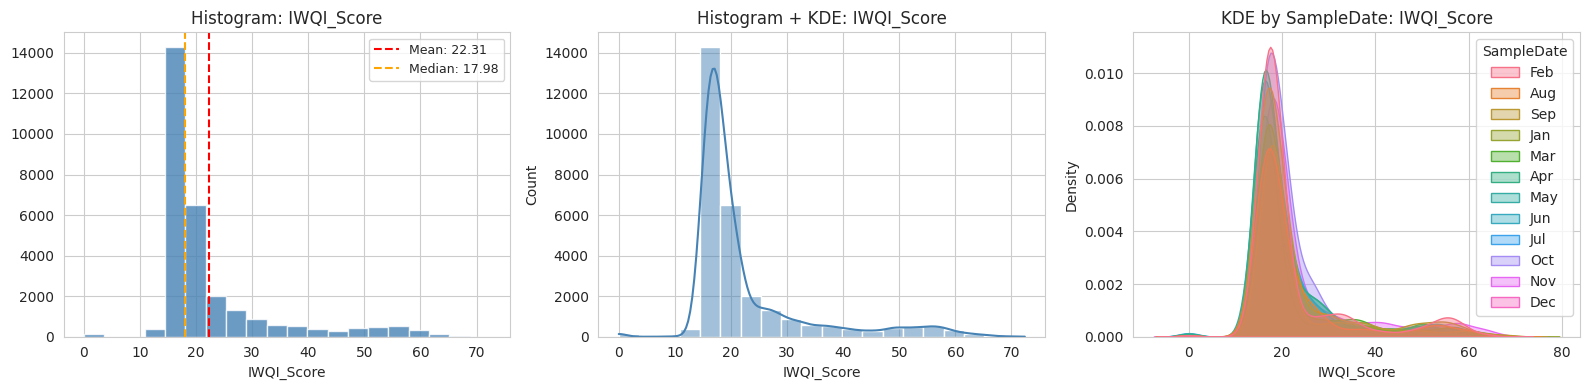

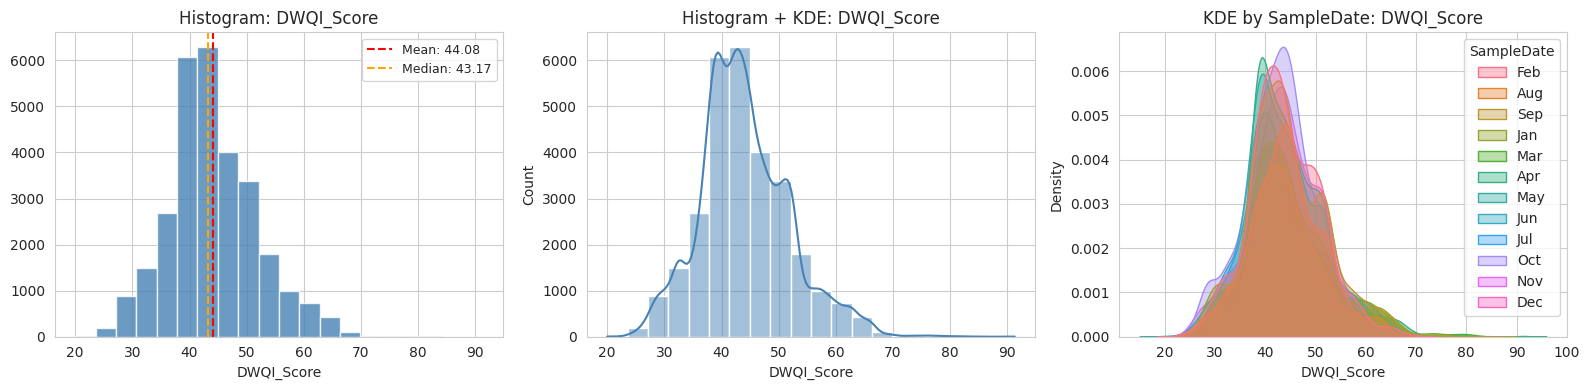

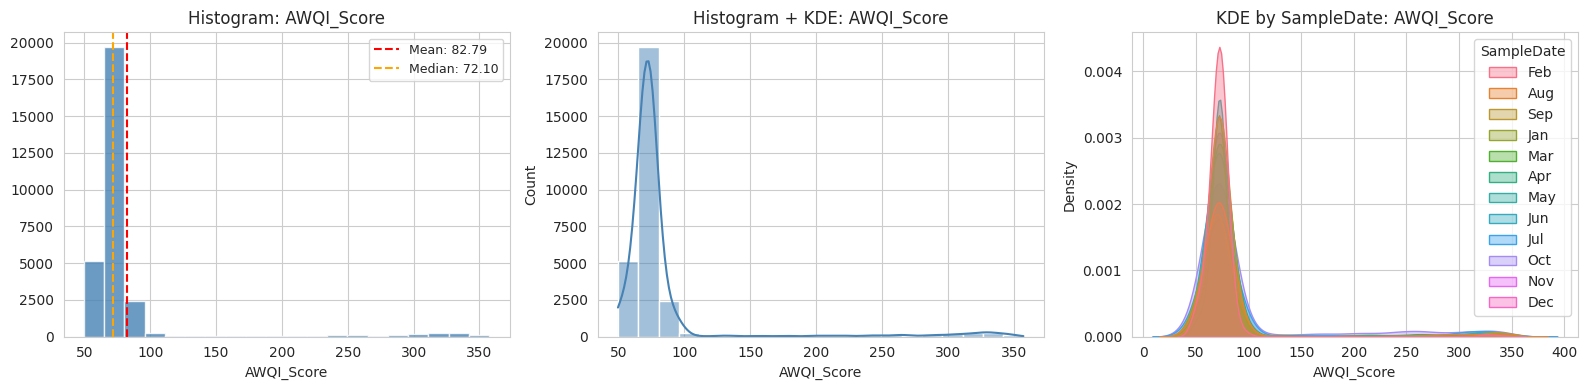

In [13]:


# Loop over each feature
for i, feature in enumerate(num_features[11:], 1):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1. Basic histogram with mean/median lines
    axes[0].hist(df[feature], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(df[feature].mean(), color='red', linestyle='--',
                    label=f"Mean: {df[feature].mean():.2f}")
    axes[0].axvline(df[feature].median(), color='orange', linestyle='--',
                    label=f"Median: {df[feature].median():.2f}")
    axes[0].set_title(f'Histogram: {feature}')
    axes[0].set_xlabel(feature)
    axes[0].legend(fontsize=9)

    # 2. Histogram + KDE
    sns.histplot(df[feature], kde=True, bins=20, ax=axes[1], color='steelblue')
    axes[1].set_title(f'Histogram + KDE: {feature}')

    # 3. KDE by categorical feature (if exists) or plain KDE
    categorical_feature = "SampleDate"  # replace if another categorical feature exists
    if categorical_feature in df.columns:
        sns.kdeplot(data=df, x=feature, hue=categorical_feature, fill=True, ax=axes[2], alpha=0.4)
        axes[2].set_title(f'KDE by {categorical_feature}: {feature}')
    else:
        sns.kdeplot(df[feature], ax=axes[2], fill=True, color='steelblue', alpha=0.4)
        axes[2].set_title(f'KDE: {feature}')

    plt.tight_layout()
    plt.show()

In [14]:

# # Melt the dataframe so that features become a categorical column
# df_melted = df[num_features].melt(var_name='Feature', value_name='Value')

# # Plot
# plt.figure(figsize=(15, 8))
# sns.violinplot(x='Feature', y='Value', data=df_melted, palette='pastel', inner='quartile')
# plt.xticks(rotation=45)
# plt.title("Figure 14: Violin Plot of All Numeric Features")
# plt.xlabel("Features")
# plt.ylabel("Value")
# plt.tight_layout()
# plt.show()

/tmp/ipykernel_335/520537645.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Feature', y='Value', data=df_melted, palette='pastel', inner='quartile')


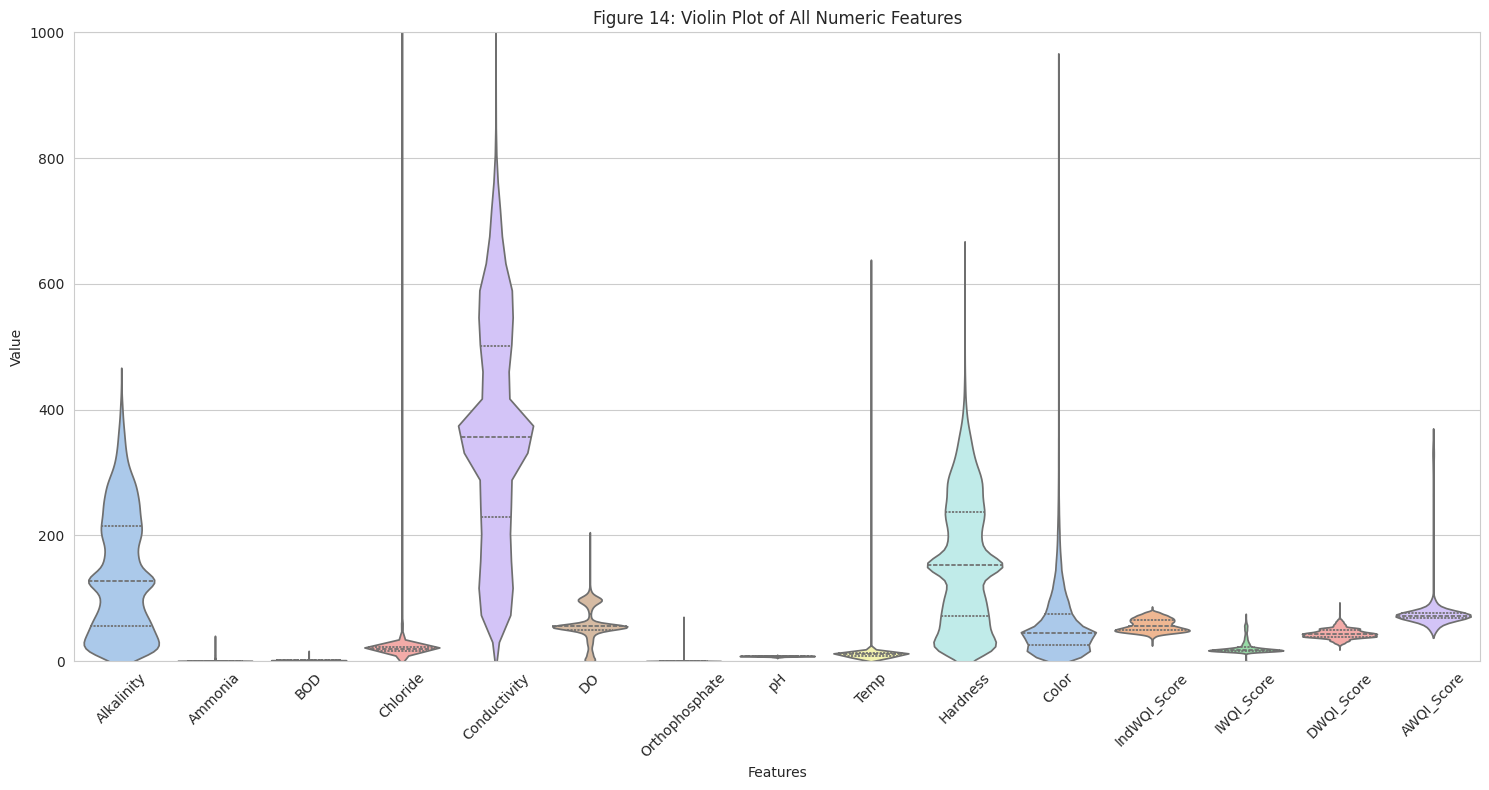

In [15]:
# Melt the dataframe so that features become a categorical column
df_melted = df[num_features].melt(var_name='Feature', value_name='Value')

# Plot
plt.figure(figsize=(15, 8))
sns.violinplot(x='Feature', y='Value', data=df_melted, palette='pastel', inner='quartile')
plt.xticks(rotation=45)
plt.title("Figure 14: Violin Plot of All Numeric Features")
plt.xlabel("Features")
plt.ylabel("Value")

plt.ylim(0, 1000)  # Set y-axis max to 2000

plt.tight_layout()
plt.show()

           Feature   Skewness     Kurtosis Is_Normal Num_Outliers
0       Alkalinity   0.484602    -0.704908     False            0
1          Ammonia  56.327093  4673.331834     False        12879
2              BOD   8.103517   119.453743     False         8606
3         Chloride  44.313625  2559.327333     False         1861
4     Conductivity   1.297621    20.997343     False           20
5               DO  -0.026754    -0.133513     False         2314
6   Orthophosphate  38.374286  2025.281042     False         6229
7               pH  -0.935719     0.749148     False          406
8             Temp  61.211265  7331.807949     False          134
9         Hardness   0.354629     -0.76224     False            3
10           Color   3.523792    29.994634     False         1685
11    IndWQI_Score   0.306403    -0.910869     False            0
12      IWQI_Score   2.151419     4.189202     False         4141
13      DWQI_Score   0.545878     0.769474     False          506
14      AW

/tmp/ipykernel_42660/1679788174.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Feature", y="Num_Outliers", data=stats_df, palette="pastel")


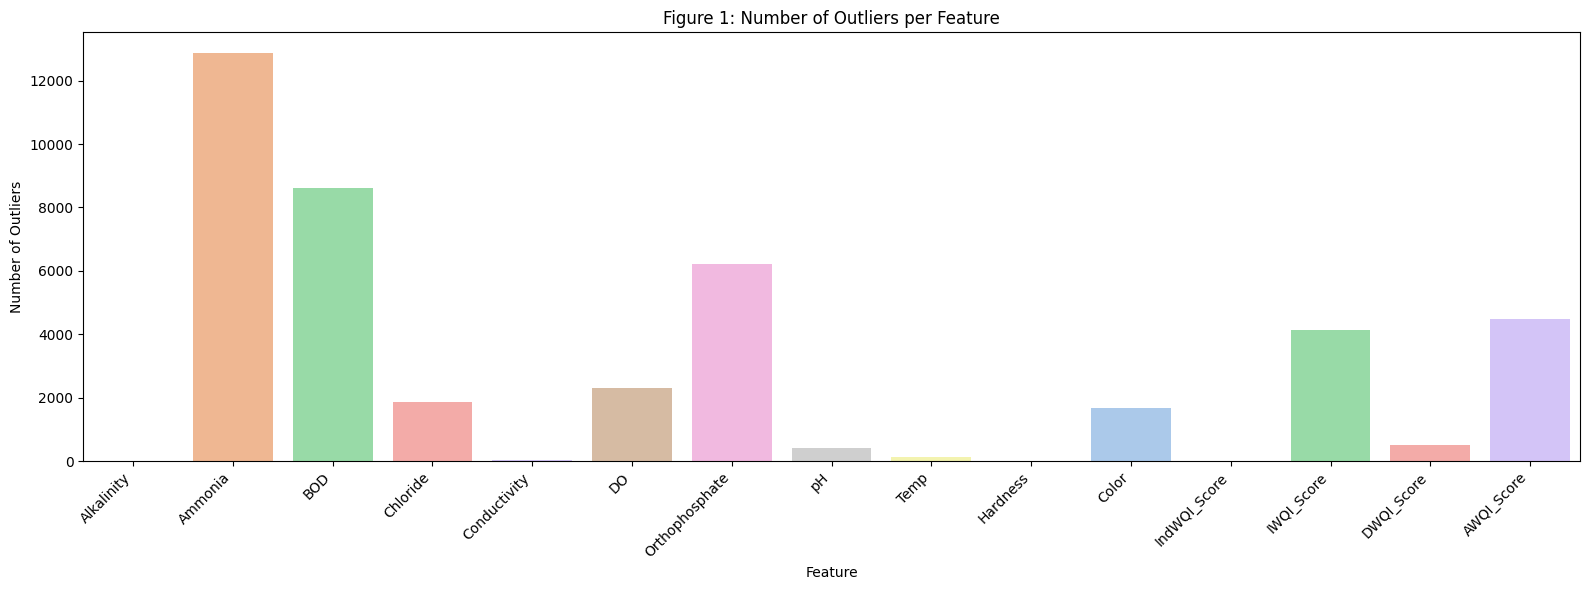

/tmp/ipykernel_42660/1679788174.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Feature", y="Skewness", data=stats_df, palette="coolwarm")


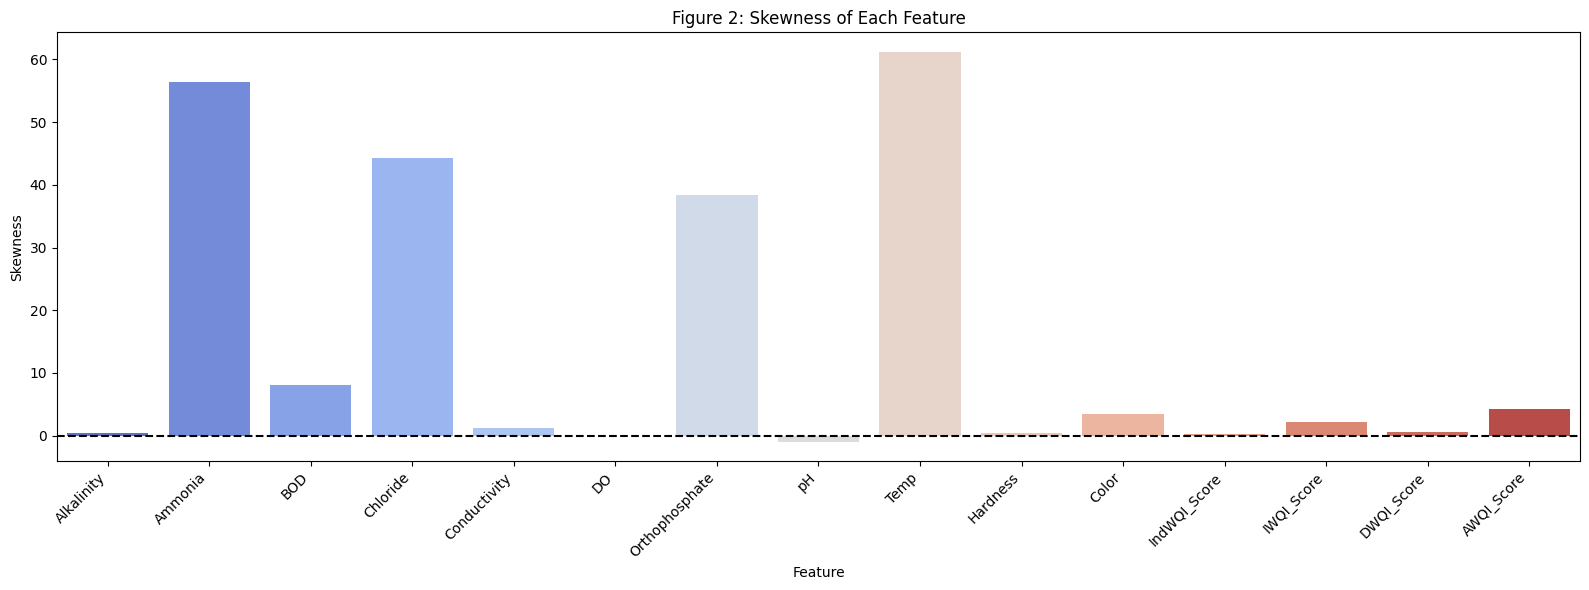

/tmp/ipykernel_42660/1679788174.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Feature", y="Kurtosis", data=stats_df, palette="magma")


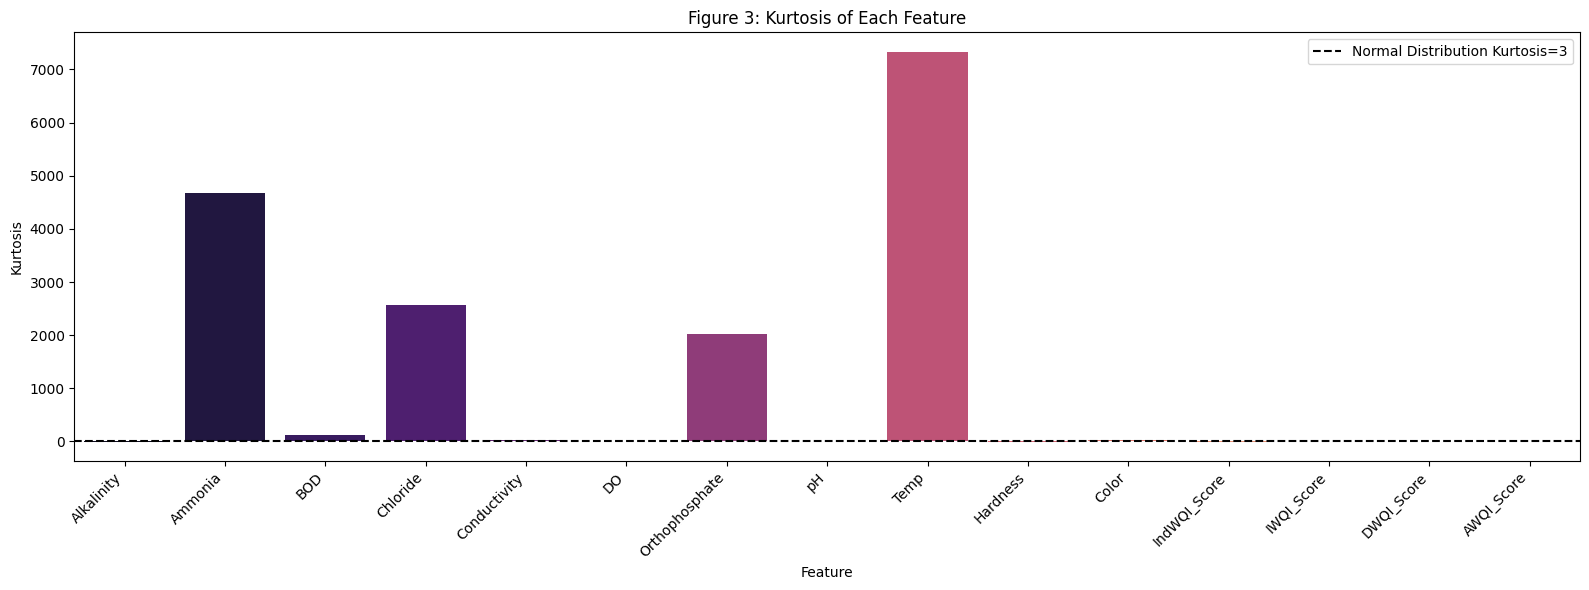

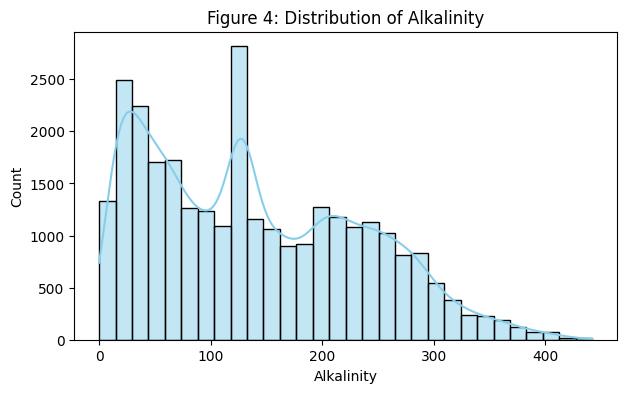

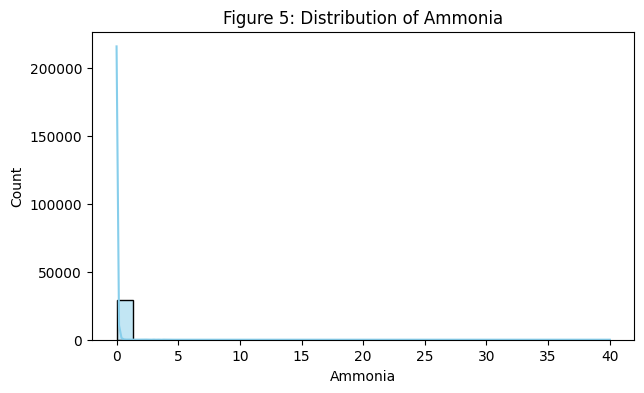

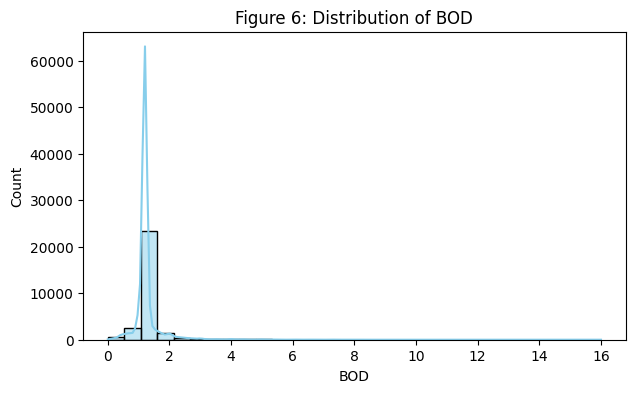

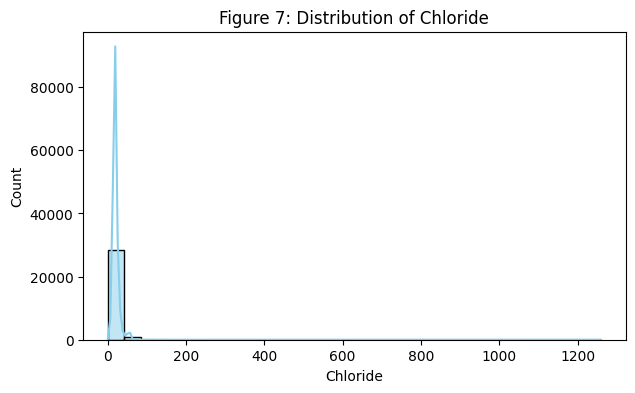

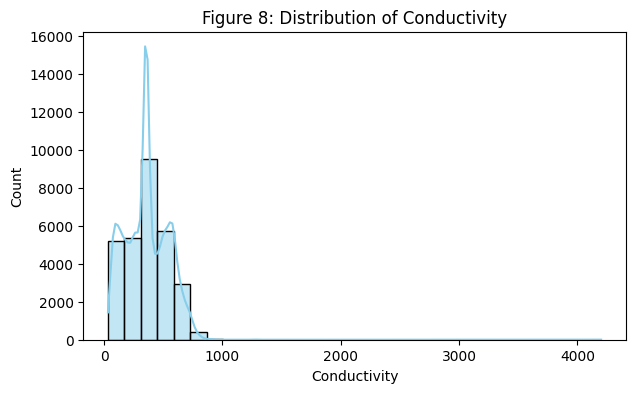

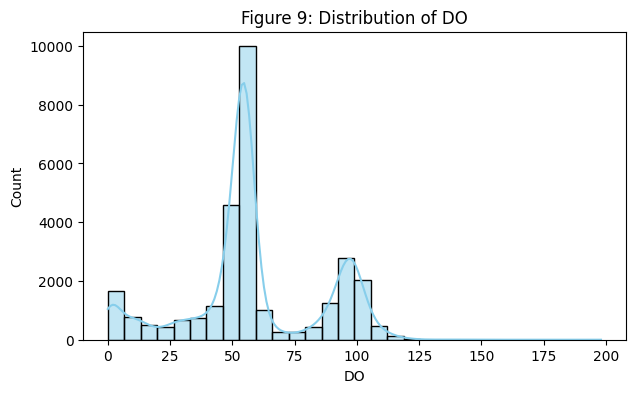

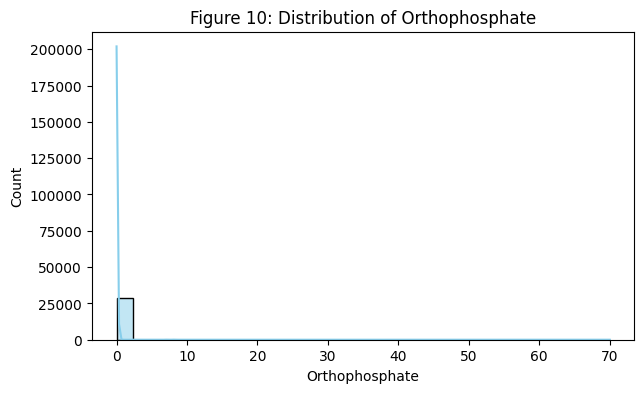

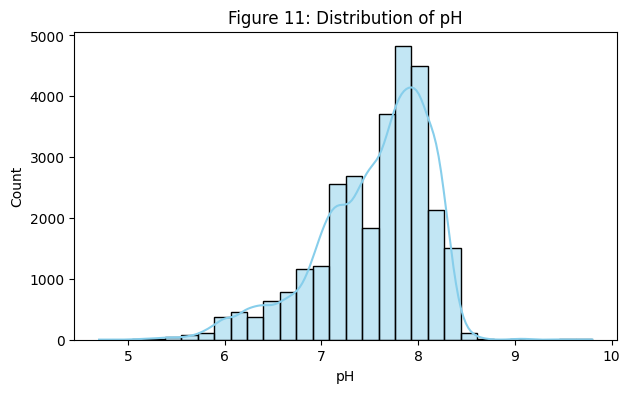

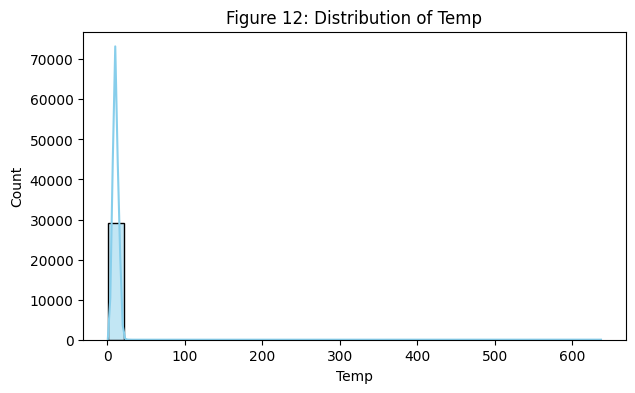

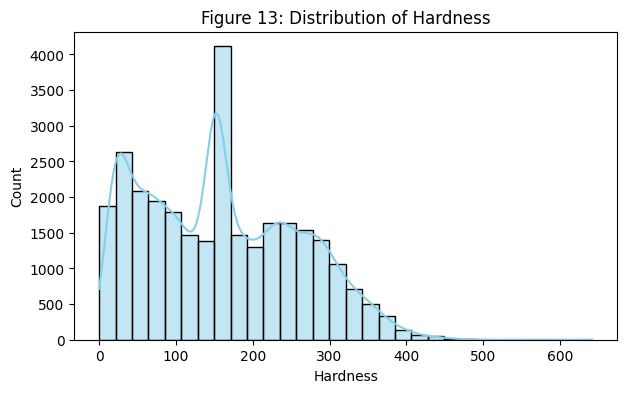

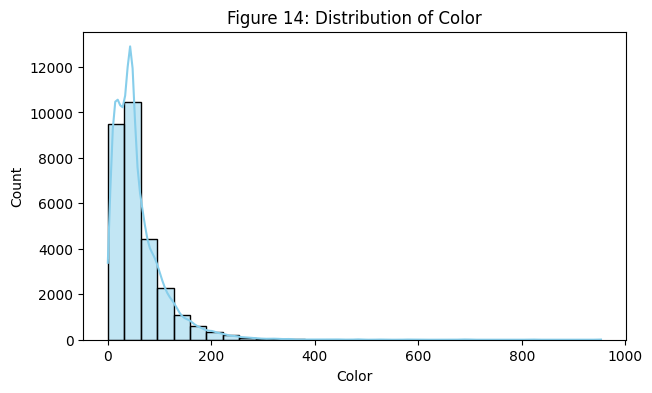

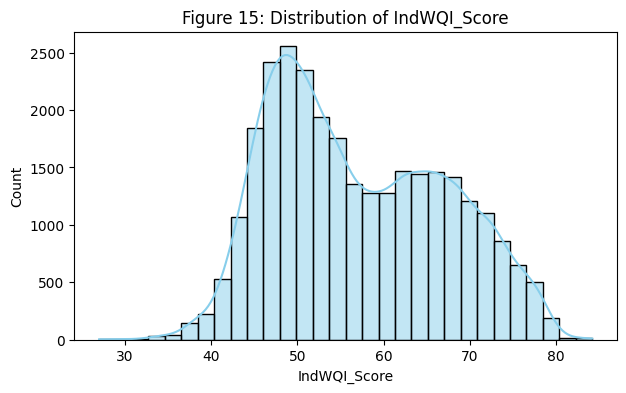

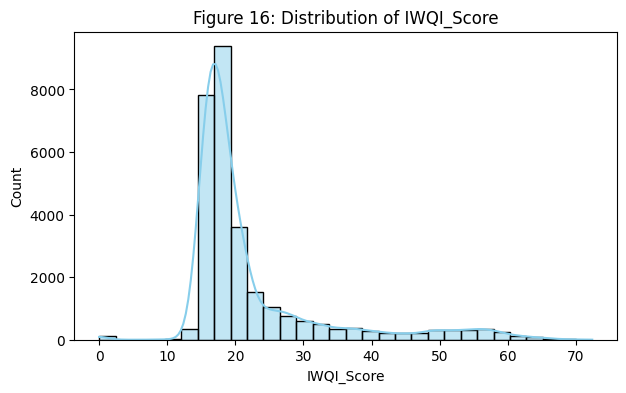

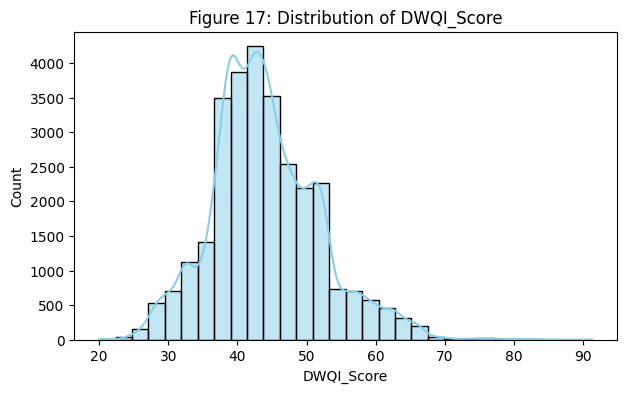

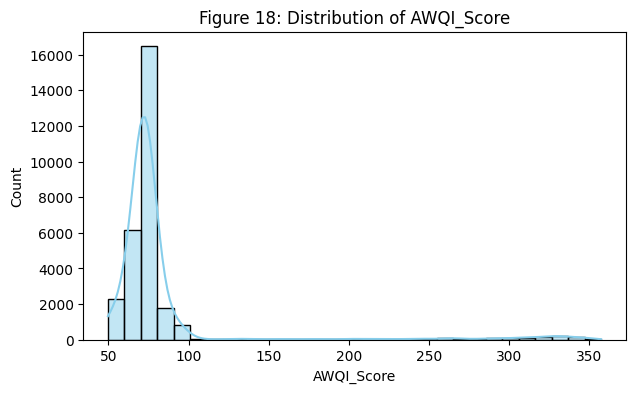

In [ ]:
from scipy import stats

# Function to calculate stats for a series
def feature_stats(series):
    series = series.dropna()

    # Skewness and kurtosis
    skewness = series.skew()
    kurtosis = series.kurtosis()

    # Normality (Shapiro-Wilk test, sample if large)
    if len(series) >= 3:
        stat, p_value = stats.shapiro(series.sample(n=min(5000, len(series)), random_state=42))
        is_normal = p_value > 0.05
    else:
        is_normal = False

    # Outliers using IQR
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()

    return pd.Series({
        "Skewness": skewness,
        "Kurtosis": kurtosis,
        "Is_Normal": is_normal,
        "Num_Outliers": n_outliers
    })

# Apply to all numeric features
stats_df = df[num_features].apply(feature_stats).T
stats_df = stats_df.reset_index().rename(columns={"index": "Feature"})
print(stats_df)

# -----------------------------
# Visualization
# -----------------------------

plt.figure(figsize=(16,6))
sns.barplot(x="Feature", y="Num_Outliers", data=stats_df, palette="pastel")
plt.xticks(rotation=45, ha='right')
plt.title("Figure 1: Number of Outliers per Feature")
plt.ylabel("Number of Outliers")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

# Skewness plot
plt.figure(figsize=(16,6))
sns.barplot(x="Feature", y="Skewness", data=stats_df, palette="coolwarm")
plt.xticks(rotation=45, ha='right')
plt.title("Figure 2: Skewness of Each Feature")
plt.ylabel("Skewness")
plt.xlabel("Feature")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Kurtosis plot
plt.figure(figsize=(16,6))
sns.barplot(x="Feature", y="Kurtosis", data=stats_df, palette="magma")
plt.xticks(rotation=45, ha='right')
plt.title("Figure 3: Kurtosis of Each Feature")
plt.ylabel("Kurtosis")
plt.xlabel("Feature")
plt.axhline(3, color='black', linestyle='--', label="Normal Distribution Kurtosis=3")
plt.legend()
plt.tight_layout()
plt.show()

# Distribution plots (hist + KDE) for all features
for i, feature in enumerate(num_features, 1):
    plt.figure(figsize=(7,4))
    sns.histplot(df[feature], kde=True, color='skyblue', bins=30)
    plt.title(f"Figure {i+3}: Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

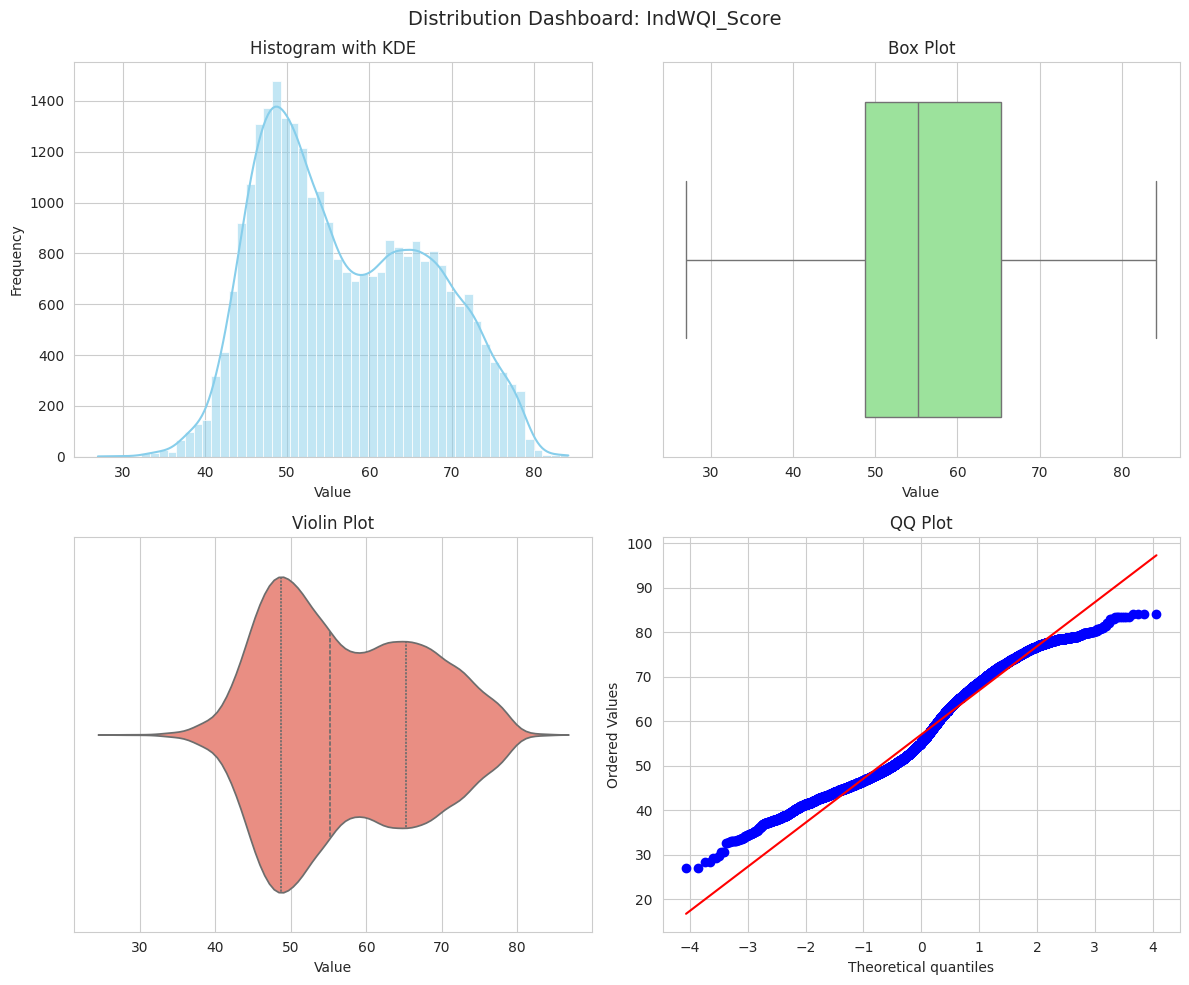

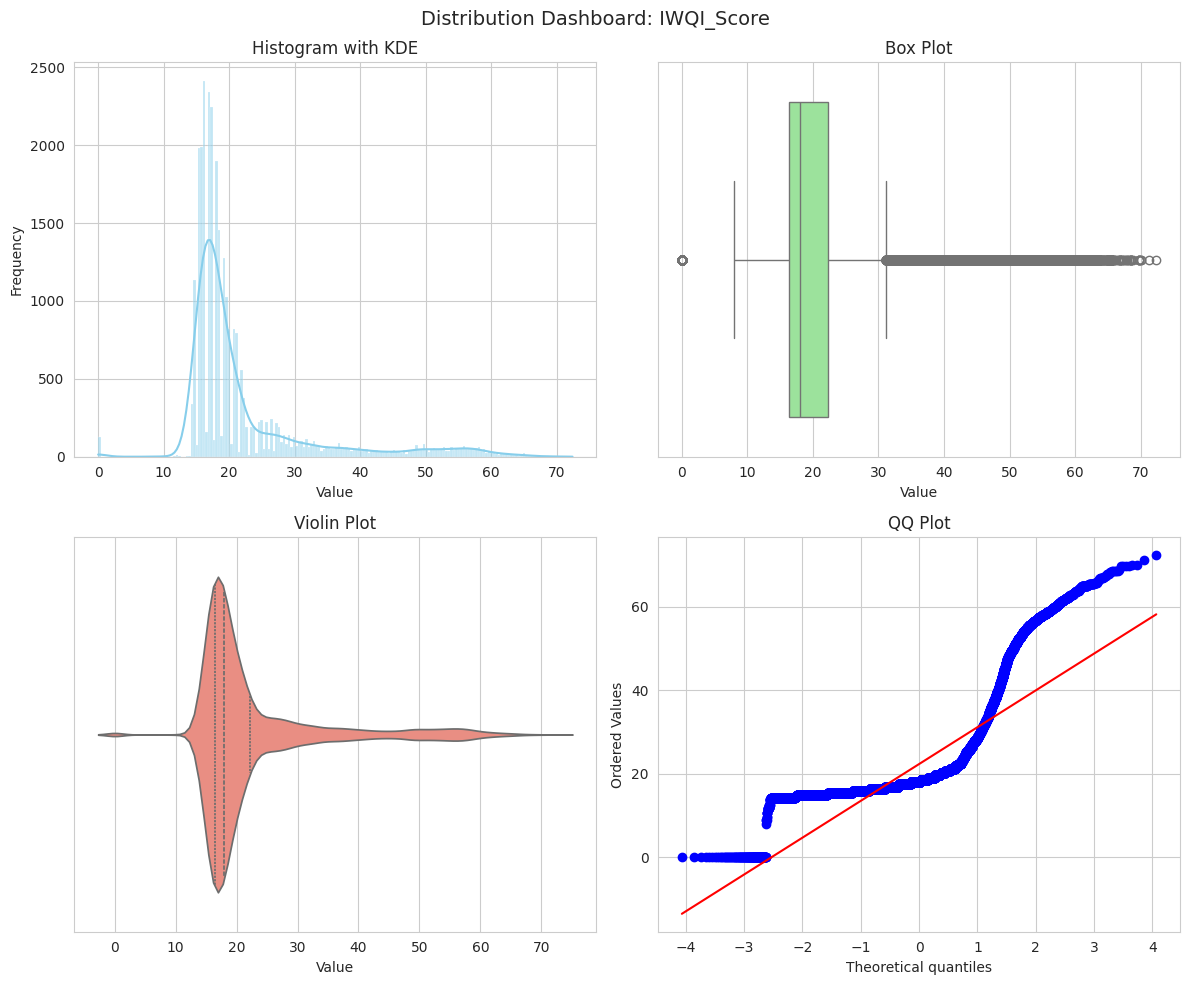

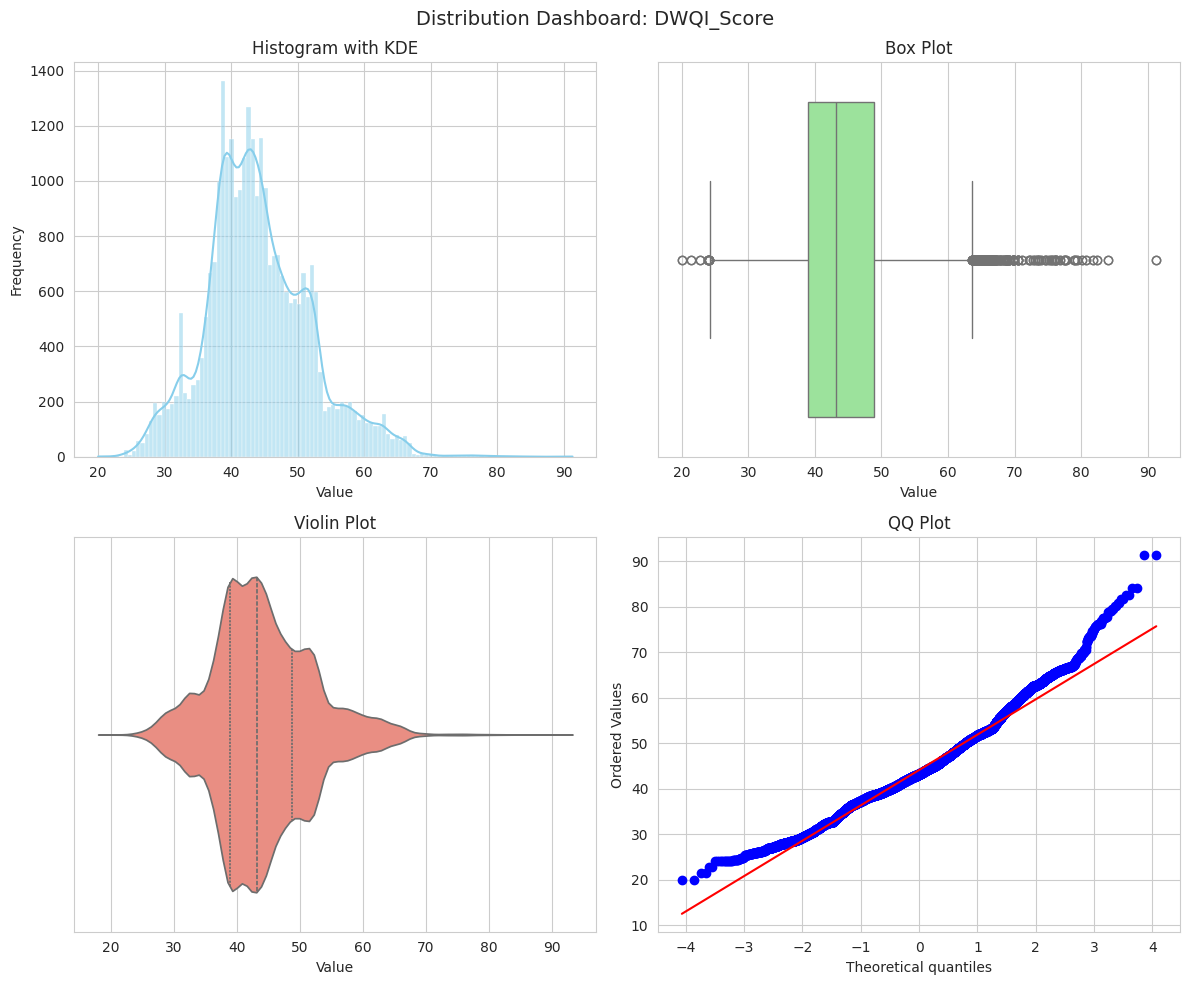

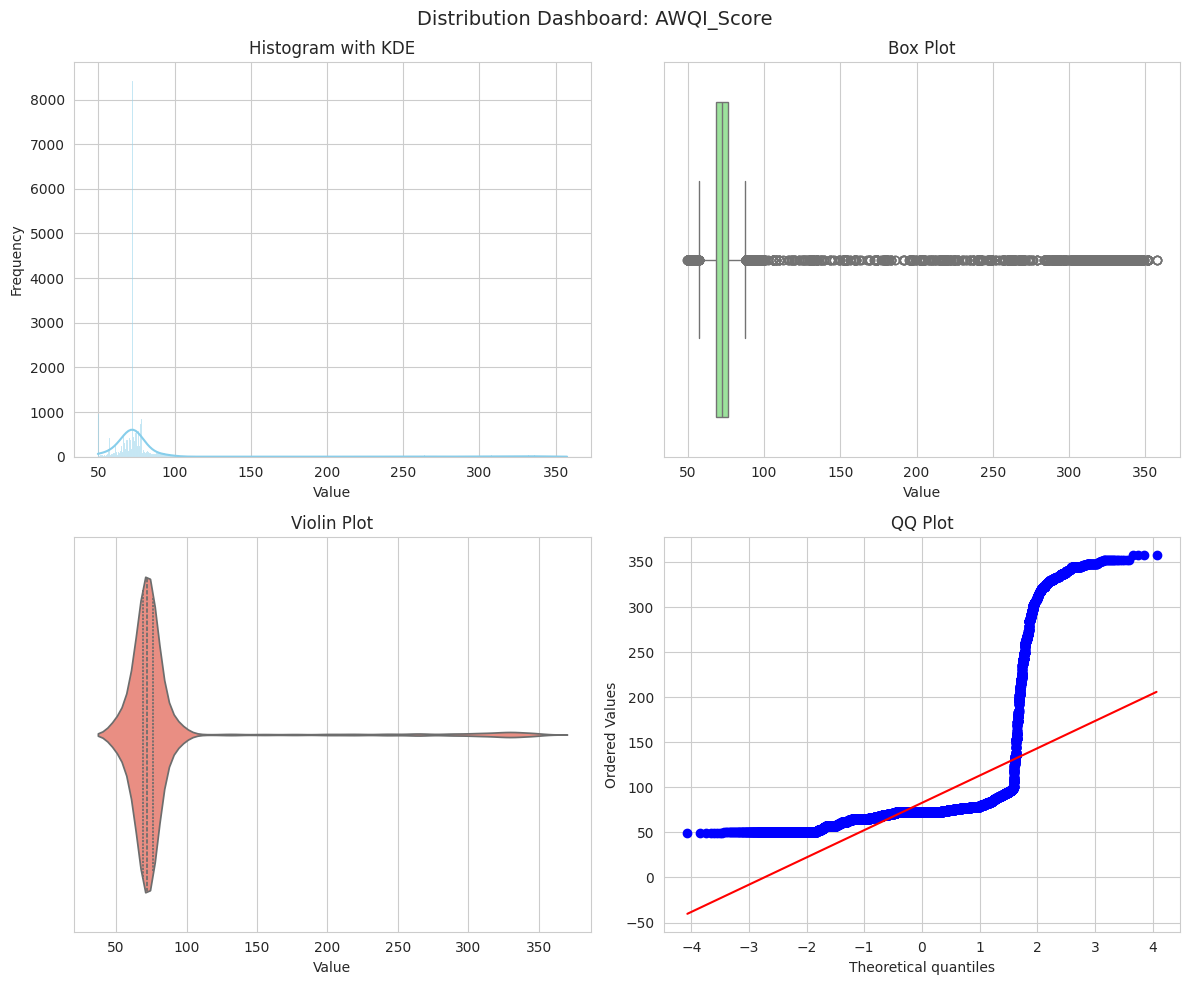

,Feature,is_normal,skewness,kurtosis,n_outliers
0,Distribution Dashboard: IndWQI_Score,True,0.3064,-0.9109,0
1,Distribution Dashboard: IWQI_Score,False,2.1514,4.1892,4141
2,Distribution Dashboard: DWQI_Score,True,0.5459,0.7695,506
3,Distribution Dashboard: AWQI_Score,False,4.2065,17.0374,4476


In [18]:
from scipy import stats
# Function to create distribution dashboard
def distribution_dashboard(series, title=""):
    """
    Create 2x2 distribution dashboard and return shape statistics.

    Parameters:
        series (pd.Series): Numeric column
        title (str): Column name for figure title

    Returns:
        dict: {is_normal, skewness, kurtosis, n_outliers}
    """

    # Remove missing values
    data = series.dropna()

    # --------- OUTLIERS (IQR method) ---------
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    n_outliers = len(outliers)

    # --------- NORMALITY TEST (Shapiro) ---------
    if len(data) > 50:
        sample_data = data.sample(50, random_state=42)
    else:
        sample_data = data
    shapiro_stat, shapiro_p = stats.shapiro(sample_data)
    is_normal = shapiro_p > 0.05

    # --------- SKEWNESS & KURTOSIS ---------
    skewness = round(data.skew(), 4)
    kurtosis = round(data.kurt(), 4)

    # --------- PLOTTING ---------
    plt.figure(figsize=(12, 10))
    if title:
        plt.suptitle(title, fontsize=14)

    # Top-left: Histogram + KDE
    plt.subplot(2, 2, 1)
    sns.histplot(data, kde=True, color='skyblue')
    plt.title("Histogram with KDE")
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    # Top-right: Box plot (horizontal)
    plt.subplot(2, 2, 2)
    sns.boxplot(x=data, color='lightgreen')
    plt.title("Box Plot")
    plt.xlabel("Value")

    # Bottom-left: Violin plot
    plt.subplot(2, 2, 3)
    sns.violinplot(x=data, color='salmon', inner='quartile')
    plt.title("Violin Plot")
    plt.xlabel("Value")

    # Bottom-right: QQ plot
    plt.subplot(2, 2, 4)
    stats.probplot(data, plot=plt)
    plt.title("QQ Plot")

    plt.tight_layout()
    plt.show()

    return {
        "Feature": title,
        "is_normal": is_normal,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "n_outliers": n_outliers
    }

# --------- Generate dashboard for all features ---------
feature_stats_list = []

for feature in num_features[11:]:
    stats_dict = distribution_dashboard(df[feature], title=f"Distribution Dashboard: {feature}")
    feature_stats_list.append(stats_dict)

# Convert stats to DataFrame for summary
feature_stats_df = pd.DataFrame(feature_stats_list)
feature_stats_df

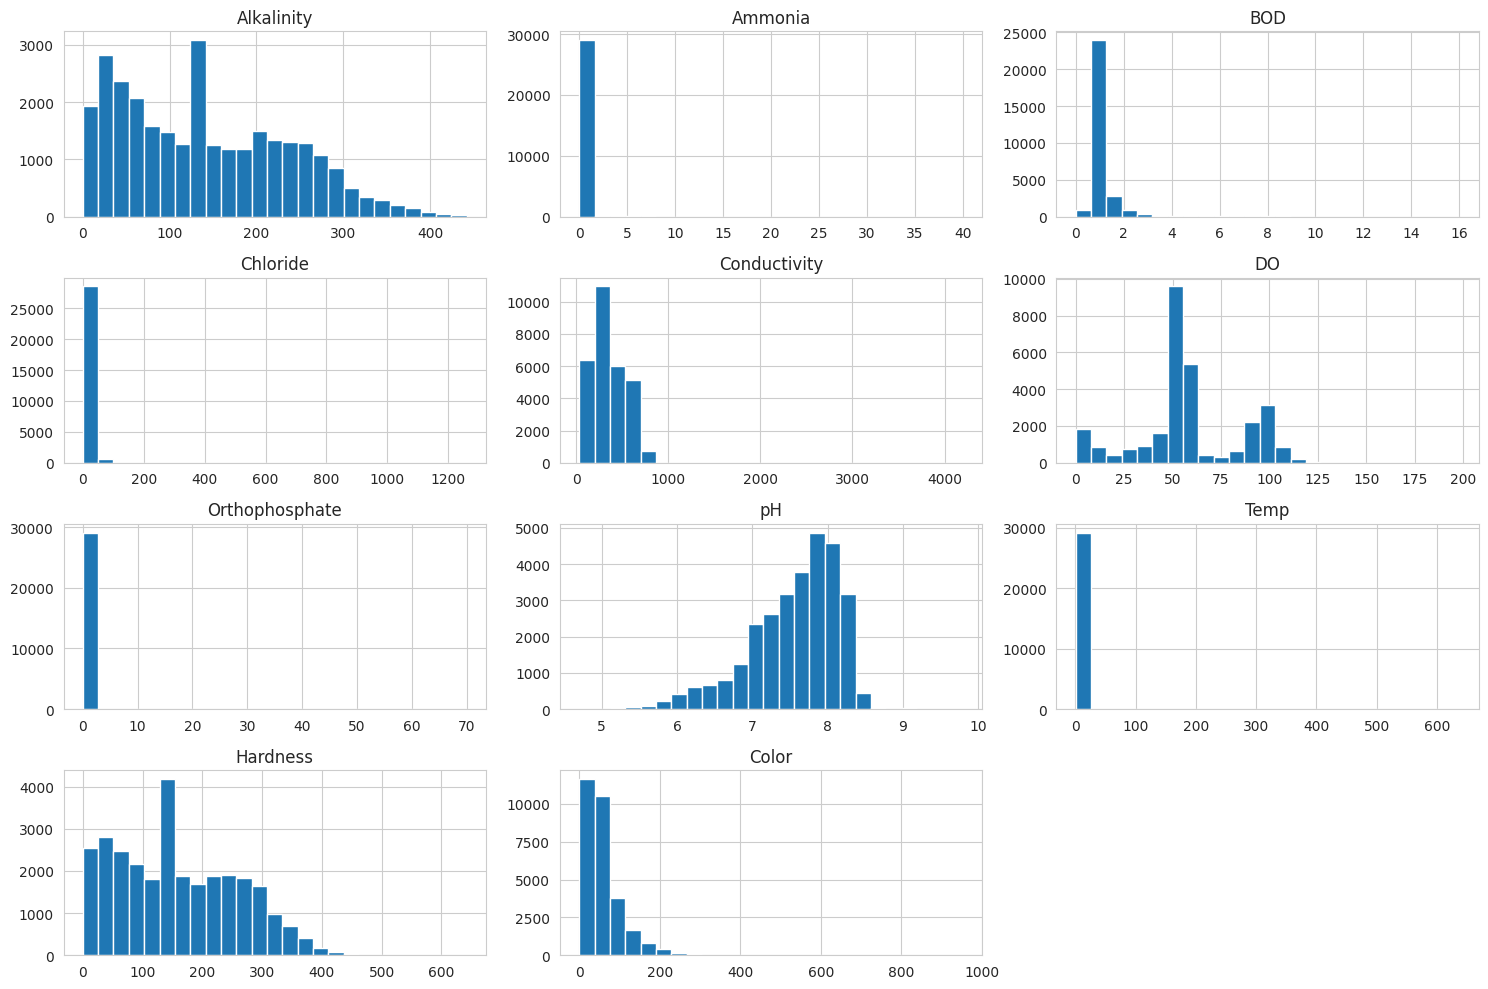

In [19]:
df[num_features[:11]].hist(figsize=(15, 10), bins=25)
plt.tight_layout()
plt.show()

In [21]:
# Use boxplots for outlier detection
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[num_features])
plt.xticks(rotation=45)
plt.title("Boxplot of Water Quality Parameters")
plt.show()

Water Quality Indices Can not be calculated using NULL values. Therefore, we need to impute it first. As data distribution is not regular, we need to do median imputaiton.

In [ ]:
df.isnull().sum()

,0
WaterbodyName,0
Years,0
SampleDate,0
Alkalinity,0
Ammonia,0
BOD,0
Chloride,0
Conductivity,0
DO,0
Orthophosphate,0


# **1. Missing Value Analysis:**

Median Imputatation Done Before Calculating WQI's

In [ ]:
# # Apply median imputation
# for col in num_features:
#     df[col].fillna(df[col].median(), inplace=True)

# **2. Data Type Conversion::**

All water quality parameters found from the data source was in unified data type. Therefore we did not had to make any explicit conversions. As we will work on regressive model, any encoding is not required still.



# **3. Outlier Detection and Treatment:**



**IQR Method for Outlier Detection**

In [ ]:
outliers_iqr = {}

for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_iqr[col] = len(outliers)

print("Number of outliers detected via IQR method:")
for col, count in outliers_iqr.items():
    print(f"{col}: {count}")

Number of outliers detected via IQR method:
Alkalinity: 0
Ammonia: 12879
BOD: 8606
Chloride: 1861
Conductivity: 20
DO: 2314
Orthophosphate: 6229
pH: 406
Temp: 134
Hardness: 3
Color: 1685
IndWQI_Score: 0
IWQI_Score: 4141
DWQI_Score: 506
AWQI_Score: 4476


**Z-score Method for Outlier Detection**

Z-Score is preferable as we need to exclude less outliers. All WQI's are eaqual important, whether its outlier or not.

In [ ]:
from scipy import stats

outliers_z = {}

for col in num_features:
    z_scores = np.abs(stats.zscore(df[col].fillna(df[col].median())))
    outliers = np.where(z_scores > 3)[0]  # threshold: 3 std dev
    outliers_z[col] = len(outliers)

print("Number of outliers detected via Z-score method:")
for col, count in outliers_z.items():
    print(f"{col}: {count}")

Number of outliers detected via Z-score method:
Alkalinity: 16
Ammonia: 150
BOD: 487
Chloride: 39
Conductivity: 20
DO: 11
Orthophosphate: 89
pH: 239
Temp: 6
Hardness: 16
Color: 477
IndWQI_Score: 0
IWQI_Score: 1010
DWQI_Score: 112
AWQI_Score: 1194


Removing outliers using Z-Score for All numeric values

In [ ]:
from scipy import stats

# Compute Z-scores for all numerical features
z_scores = np.abs(stats.zscore(df[num_features]))
threshold = 3

# Keeping rows where all feature Z-scores are below the threshold
df_no_outliers = df[(z_scores < threshold).all(axis=1)]

print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after removing outliers: {df_no_outliers.shape}")

Original dataset shape: (29159, 22)
Dataset shape after removing outliers: (25633, 22)


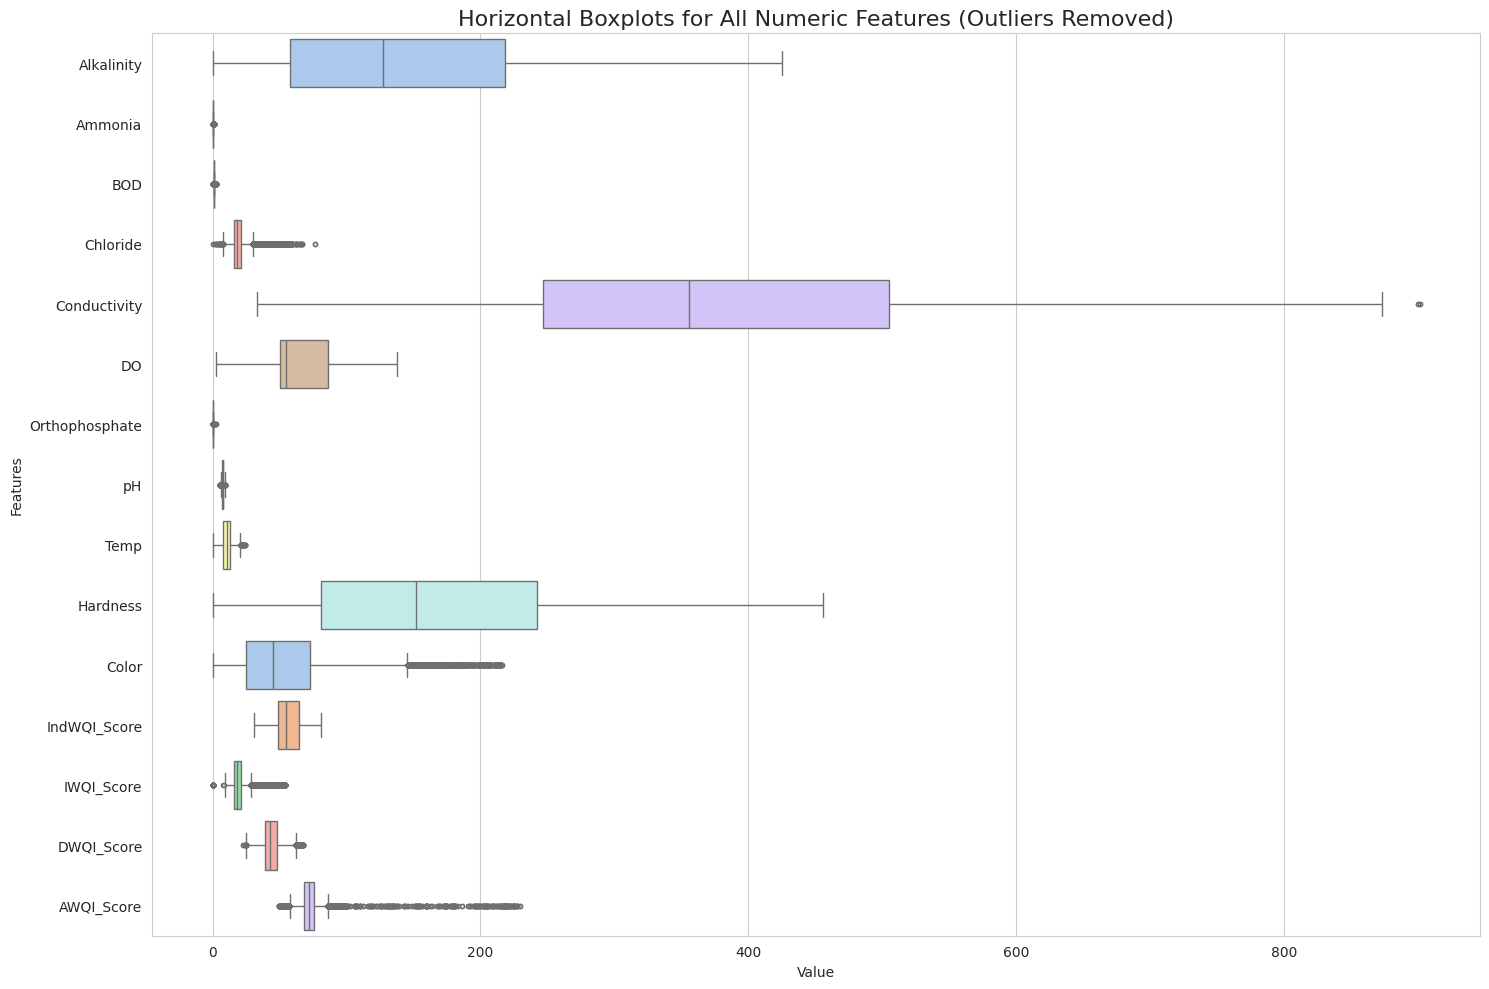

In [ ]:

plt.figure(figsize=(15, 10))
sns.boxplot(data=df_no_outliers[num_features],
            orient="h",
            palette="pastel",
            fliersize=3)
plt.title("Horizontal Boxplots for All Numeric Features (Outliers Removed)", fontsize=16)
plt.xlabel("Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [22]:

# # Pairplot with KDE on diagonals and alpha for transparency
# sns.pairplot(df_no_outliers[num_features], diag_kind='kde', plot_kws={'alpha':0.5})
# plt.suptitle("Figure 13: Pairwise Relationships (First 6 Numeric Features, Outliers Removed)", y=1.02)
# plt.show()

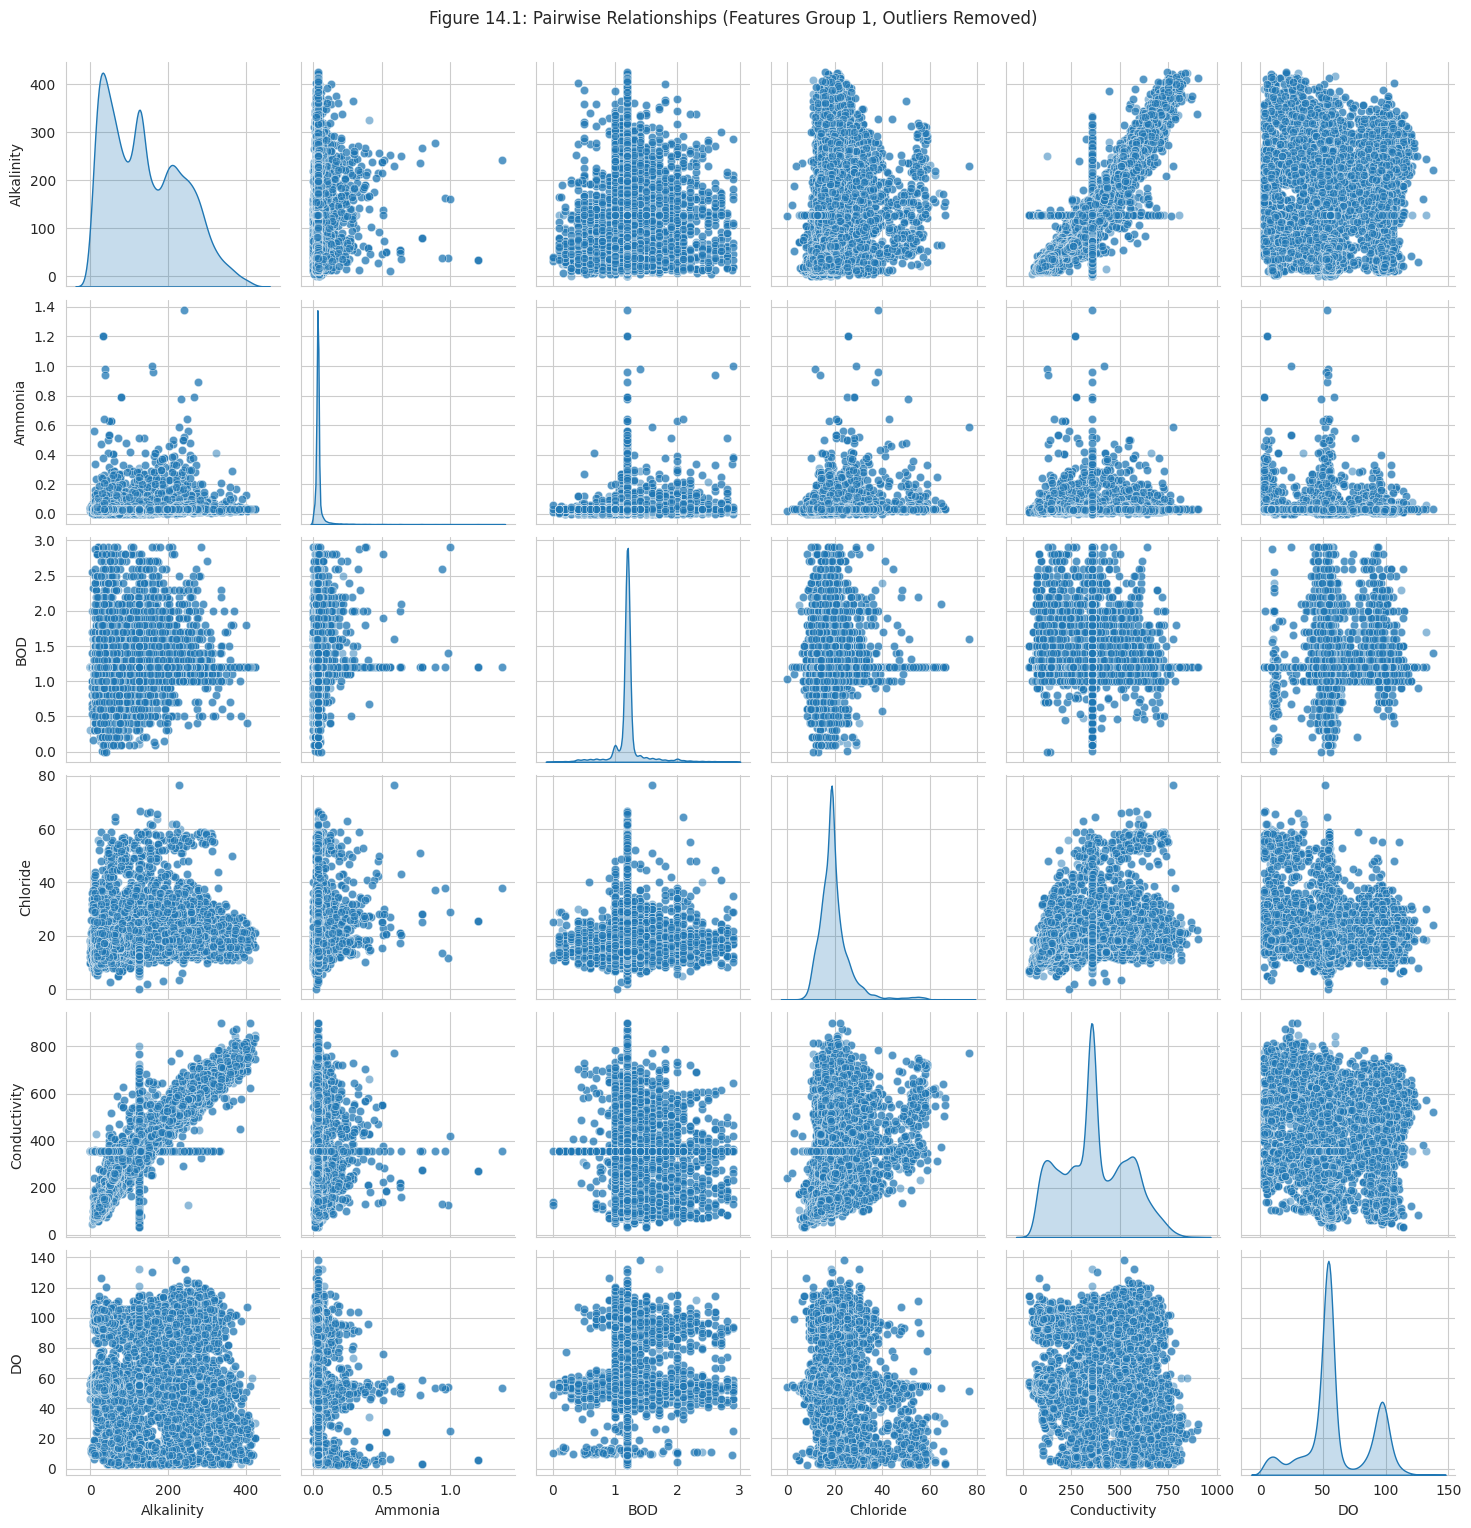

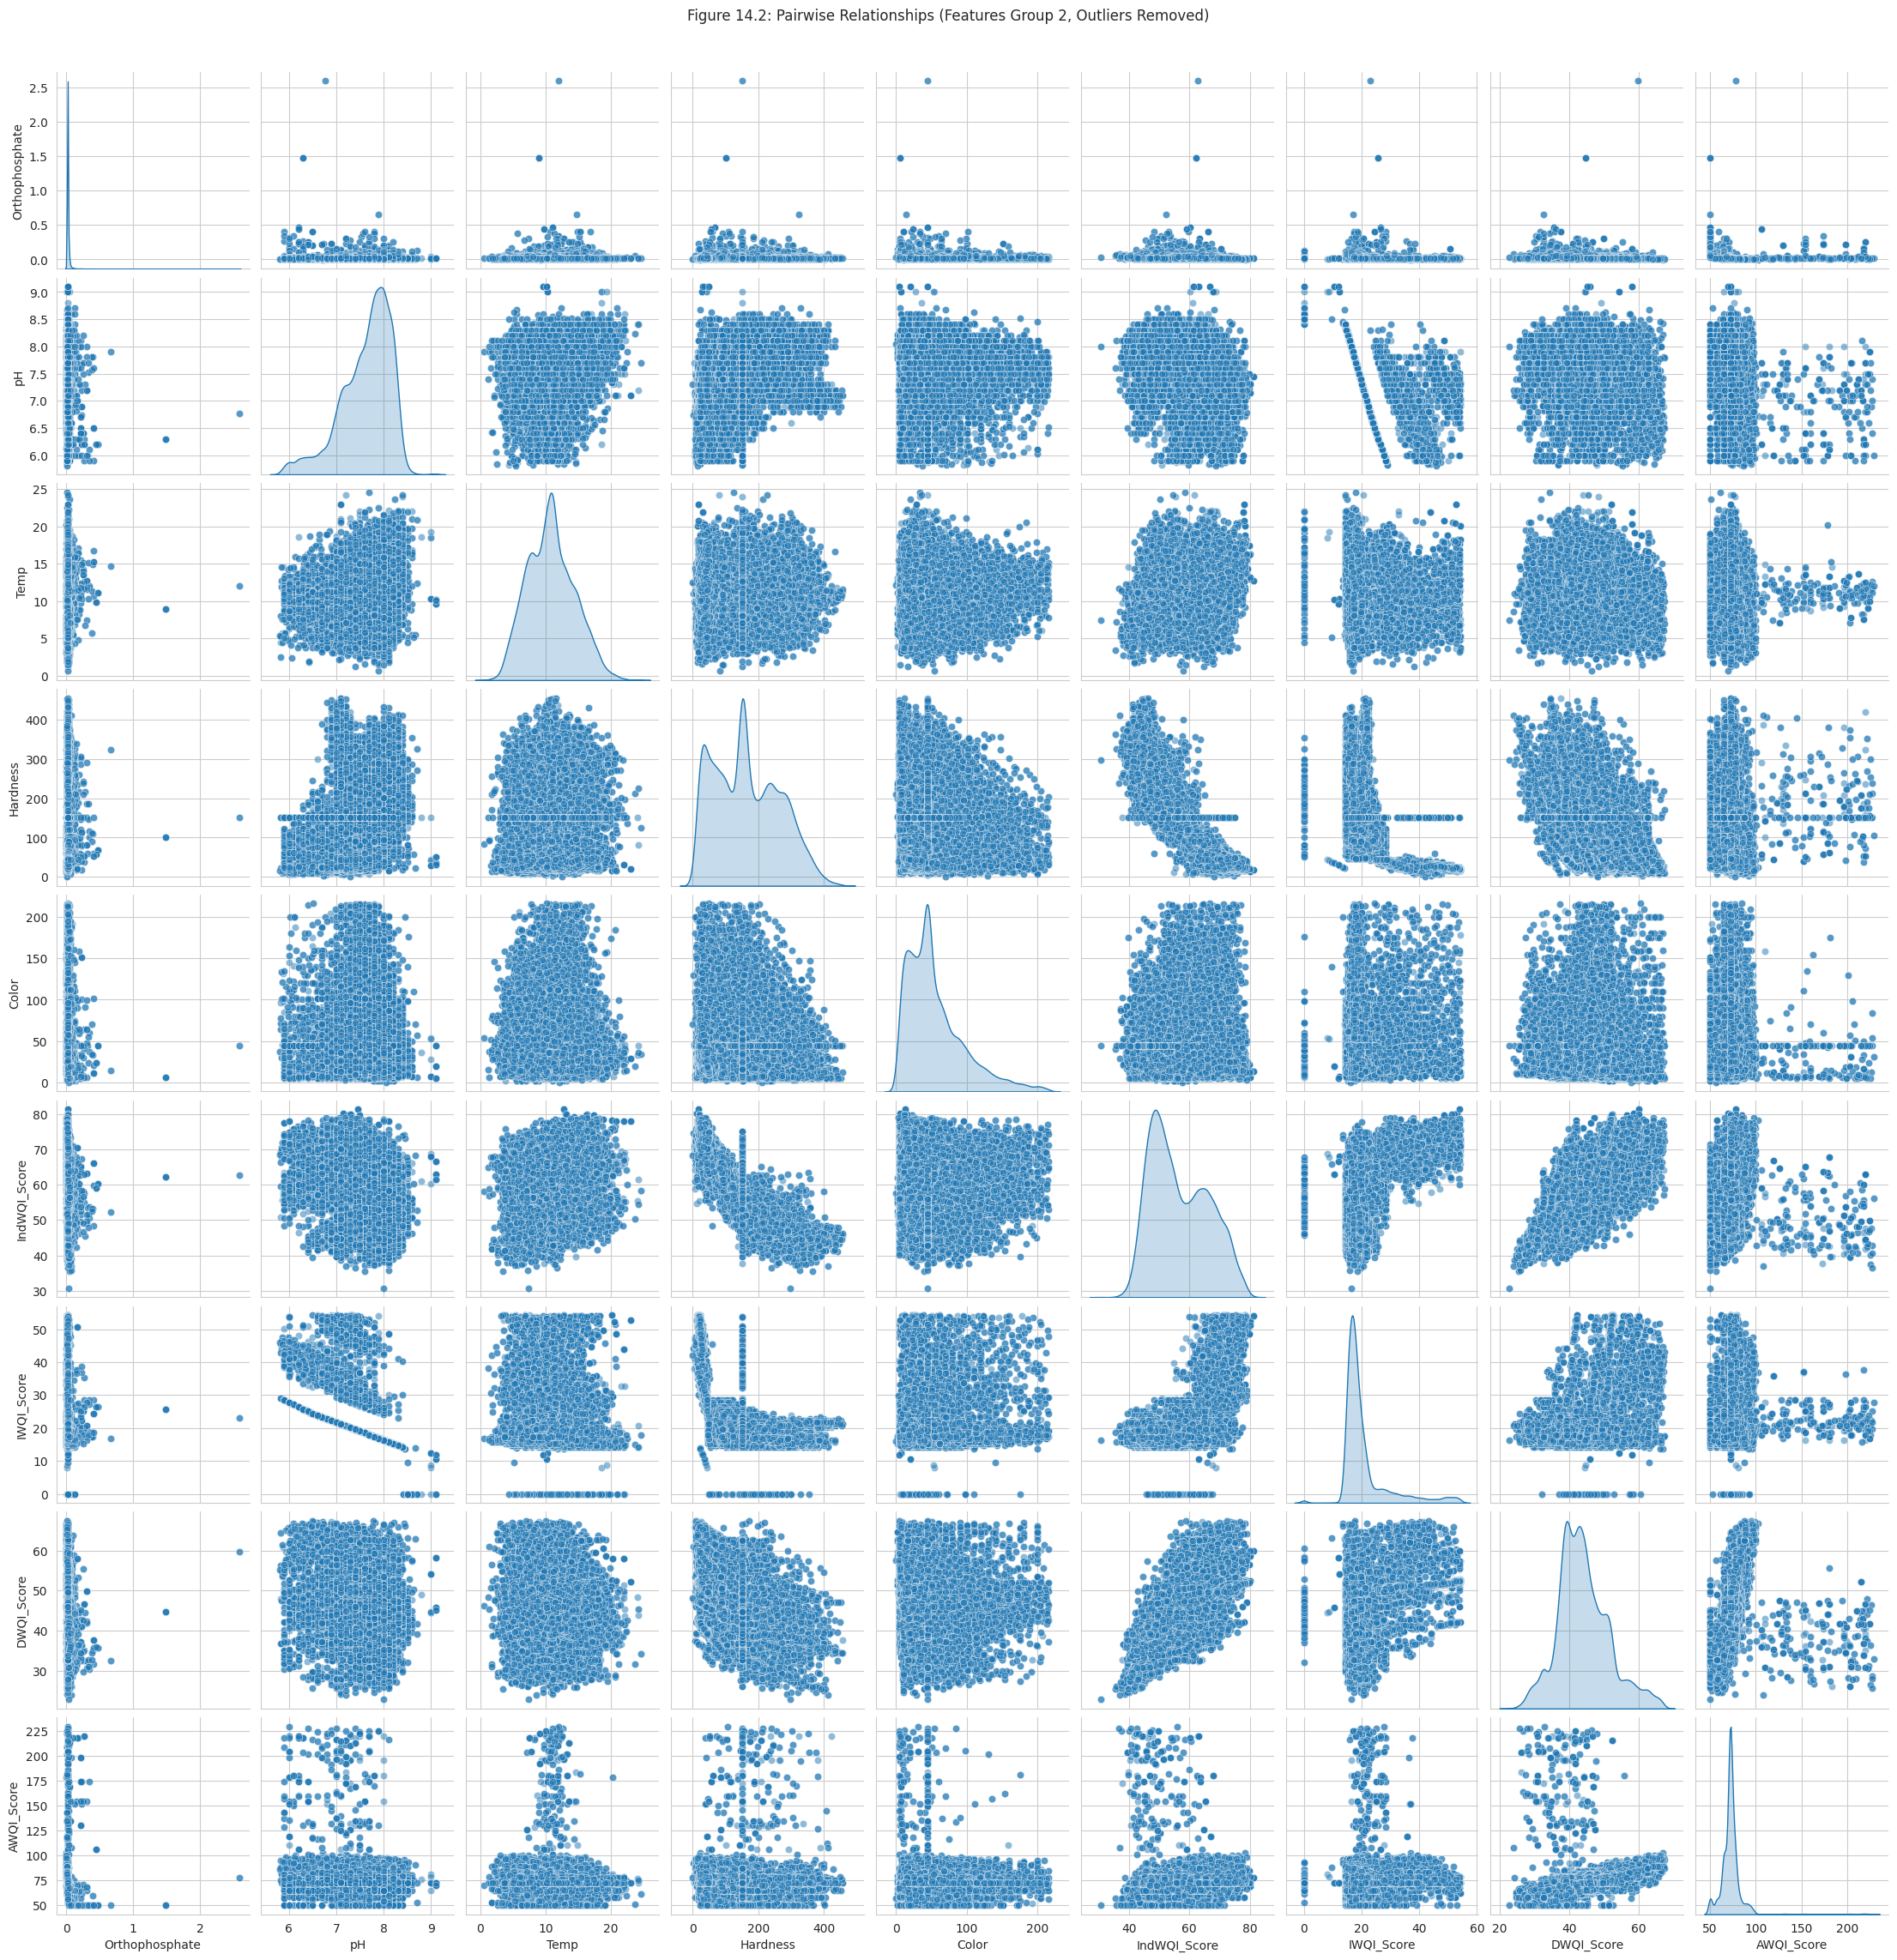

In [ ]:
# Split features into two groups for pairplot to avoid freezing
feature_groups = [num_features[:6], num_features[6:]]

for i, group in enumerate(feature_groups, 1):
    sns.pairplot(df_no_outliers[group], diag_kind='kde', plot_kws={'alpha':0.5})
    plt.suptitle(f"Figure 14.{i}: Pairwise Relationships (Features Group {i}, Outliers Removed)", y=1.02)
    plt.show()

# **4. Feature Engineering:**


# Derived Features for Water Quality Dataset

## i. BOD to DO Ratio (`BOD_DO_Ratio`)

**Definition:**  
The BOD to DO ratio measures the relative oxygen demand in water compared to the available dissolved oxygen. High values indicate oxygen stress, which can signal poor water quality.

**Mathematical Expression:**  

$$
\text{BOD_DO_Ratio} = \frac{\text{BOD}}{\text{DO} + \epsilon}
$$

**Where:**  

- **BOD** = Biochemical Oxygen Demand (mg/L)  
- **DO** = Dissolved Oxygen (mg/L)  
- **ε** = Small number to prevent division by zero (e.g., $10^{-6}$)  

**Example:**  
If BOD = 2.0 mg/L and DO = 5.0 mg/L, then:  

$$
\text{BOD_DO_Ratio} \approx 0.4
$$

**Rationale for ML Models:**  

- Combines two related water quality indicators into a single feature.  
- Can improve model sensitivity to oxygen-related water quality issues, enhancing WQI prediction.  

---

## ii. Hardness to Alkalinity Ratio (`Hardness_Alkalinity_Ratio`)

**Definition:**  
This ratio quantifies the relative contribution of water hardness to alkalinity. It reflects water scaling potential and buffering capacity.

**Mathematical Expression:**  

$$
\text{Hardness_Alkalinity_Ratio} = \frac{\text{Hardness}}{\text{Alkalinity} + \epsilon}
$$

**Where:**  

- **Hardness** = Total water hardness (mg/L as CaCO₃)  
- **Alkalinity** = Water alkalinity (mg/L as CaCO₃)  
- **ε** = Small number to prevent division by zero  

**Example:**  
If Hardness = 120 mg/L and Alkalinity = 100 mg/L, then:  

$$
\text{Hardness_Alkalinity_Ratio} \approx 1.2
$$

**Rationale for ML Models:**  

- Captures interaction between two correlated chemistry features.  
- Useful for detecting water scaling or buffering patterns that affect overall water quality.

Derived Features:

Feature 1: BOD to DO Ratio (BOD_DO_Ratio)

Rationale:

BOD (Biochemical Oxygen Demand) indicates the amount of oxygen consumed by microorganisms.
DO (Dissolved Oxygen) measures available oxygen in water.
High BOD combined with low DO often signals poor water quality.
A BOD/DO ratio can serve as a single combined feature to capture oxygen stress in the water, which may improve WQI prediction or classification.




In [ ]:
# Feature 1: BOD to DO ratio
df_no_outliers['BOD_DO_Ratio'] = df_no_outliers['BOD'] / (df_no_outliers['DO'] + 1e-6)  # small epsilon to avoid division by zero

# Inspect
df_no_outliers[['BOD', 'DO', 'BOD_DO_Ratio']].head()

/tmp/ipykernel_42660/3013845341.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['BOD_DO_Ratio'] = df_no_outliers['BOD'] / (df_no_outliers['DO'] + 1e-6)  # small epsilon to avoid division by zero


,BOD,DO,BOD_DO_Ratio
0,1.2,52.50,0.022857
2,1.2,61.80,0.019417
3,1.2,62.40,0.019231
4,1.2,66.05,0.018168
5,1.2,65.95,0.018196


Feature 2: Hardness to Alkalinity Ratio (Hardness_Alkalinity_Ratio)

Rationale:

Hardness measures Ca²⁺ and Mg²⁺ ions, while Alkalinity measures the water’s buffering capacity (mainly carbonates).
The ratio of Hardness/Alkalinity can indicate water scaling potential, which is useful in drinking water and industrial water quality assessment.
Captures the interaction between two correlated chemistry features in a single number.

In [ ]:
# Feature 2: Hardness to Alkalinity ratio
df_no_outliers['Hardness_Alkalinity_Ratio'] = df_no_outliers['Hardness'] / (df_no_outliers['Alkalinity'] + 1e-6)

# Inspect
df_no_outliers[['Hardness', 'Alkalinity', 'Hardness_Alkalinity_Ratio']].head()

/tmp/ipykernel_42660/4172953661.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['Hardness_Alkalinity_Ratio'] = df_no_outliers['Hardness'] / (df_no_outliers['Alkalinity'] + 1e-6)


,Hardness,Alkalinity,Hardness_Alkalinity_Ratio
0,370.0,314.0,1.178344
2,15.8,17.0,0.929412
3,15.9,18.0,0.883333
4,15.4,19.0,0.810526
5,17.1,19.0,0.900000


In [ ]:
df_no_outliers.head()

,WaterbodyName,Years,SampleDate,Alkalinity,Ammonia,BOD,Chloride,Conductivity,DO,Orthophosphate,...,IndWQI,IndWQI_Score,IWQI,IWQI_Score,DWQI,DWQI_Score,AWQI,AWQI_Score,BOD_DO_Ratio,Hardness_Alkalinity_Ratio
0,ABBEYTOWN_010,2023,Feb,314.0,0.033,1.2,27.3,711.0,52.50,0.019,...,Poor,42.301154,Very Bad,17.448707,Poor,35.893750,Good,72.102564,0.022857,1.178344
2,Allua,2007,Aug,17.0,0.033,1.2,11.5,79.0,61.80,0.019,...,Good,78.214201,Bad,51.709486,Medium,52.518036,Good,72.102564,0.019417,0.929412
3,Allua,2007,Aug,18.0,0.033,1.2,11.3,78.0,62.40,0.019,...,Good,78.192201,Bad,52.073298,Medium,52.538929,Good,72.102564,0.019231,0.883333
4,Allua,2007,Sep,19.0,0.033,1.2,10.5,76.0,66.05,0.019,...,Good,78.295059,Bad,54.235504,Medium,52.630000,Good,72.102564,0.018168,0.810526
5,Allua,2007,Sep,19.0,0.066,1.2,11.4,81.0,65.95,0.019,...,Good,75.503568,Bad,52.357865,Poor,42.219107,Regular,57.333333,0.018196,0.900000


# **4. Data Normalization/Scaling**

We used MinMaxScaler: to scale all features to 0–1 range (this works fine for for neural networks - our project will be on NN based):

But other scallers are used when?

Why RobustScaler:
* Uses median and IQR → robust to extreme values/outliers.
* Preserves feature distribution while limiting the influence of extreme outliers.
* Works well for water quality data, which often has skewed parameters (e.g., Ammonia, BOD).


Effect on ML models:


*   Algorithms like KNN, SVM, Gradient Boosting, Neural Networks perform better when features are scaled similarly.
*   Reduces bias from features with large magnitude (e.g., Conductivity in hundreds vs pH ~7).




**Robust Scaller**

In [ ]:
# from sklearn.preprocessing import RobustScaler

# # Define numerical columns to scale
# numerical_features = ["Alkalinity", "Ammonia", "BOD", "Chloride",
#                       "Conductivity", "DO", "Orthophosphate",
#                       "pH", "Temp", "Hardness", "Color",
#                       "BOD_DO_Ratio", "Hardness_Alkalinity_Ratio"]

# # Initialize RobustScaler
# scaler = RobustScaler()

# # Fit and transform the data
# df_scaled = df.copy()  # Keep original df intact
# df_scaled[numerical_features] = scaler.fit_transform(df[numerical_features])

# # Inspect scaled data
# df_scaled[numerical_features].describe()

**MinMax Scaller**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
df_scaled_minmax = df_no_outliers.copy()
df_scaled_minmax[num_features] = minmax_scaler.fit_transform(df_no_outliers[num_features])

In [ ]:
df_scaled_minmax.head()

,WaterbodyName,Years,SampleDate,Alkalinity,Ammonia,BOD,Chloride,Conductivity,DO,Orthophosphate,...,IndWQI,IndWQI_Score,IWQI,IWQI_Score,DWQI,DWQI_Score,AWQI,AWQI_Score,BOD_DO_Ratio,Hardness_Alkalinity_Ratio
0,ABBEYTOWN_010,2023,Feb,0.738824,0.023913,0.413793,0.356863,0.781106,0.367837,0.008853,...,Poor,0.228441,Very Bad,0.321332,Poor,0.293249,Good,0.123850,0.022857,1.178344
2,Allua,2007,Aug,0.040000,0.023913,0.413793,0.150327,0.052995,0.436599,0.008853,...,Good,0.938688,Bad,0.952271,Medium,0.665365,Good,0.123850,0.019417,0.929412
3,Allua,2007,Aug,0.042353,0.023913,0.413793,0.147712,0.051843,0.441035,0.008853,...,Good,0.938252,Bad,0.958971,Medium,0.665833,Good,0.123850,0.019231,0.883333
4,Allua,2007,Sep,0.044706,0.023913,0.413793,0.137255,0.049539,0.468022,0.008853,...,Good,0.940287,Bad,0.998790,Medium,0.667871,Good,0.123850,0.018168,0.810526
5,Allua,2007,Sep,0.044706,0.047826,0.413793,0.149020,0.055300,0.467283,0.008853,...,Good,0.885080,Bad,0.964212,Poor,0.434835,Regular,0.041711,0.018196,0.900000


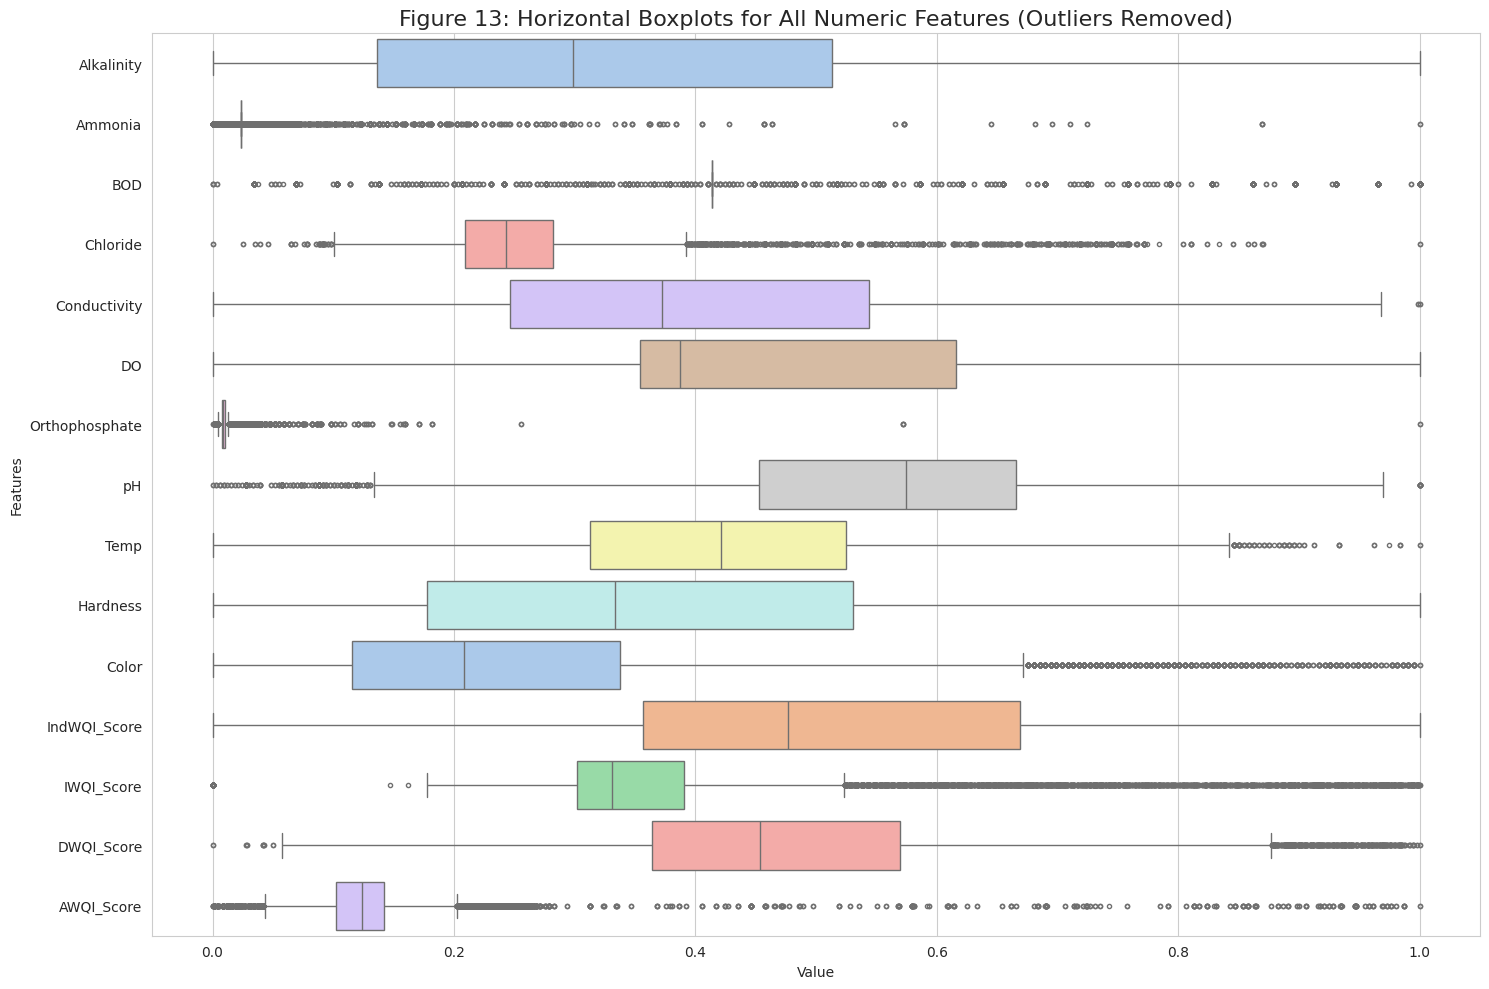

In [ ]:
# Horizontal Boxplots after removing outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_scaled_minmax[num_features],
            orient="h",
            palette="pastel",
            fliersize=3)
plt.title("Figure 13: Horizontal Boxplots for All Numeric Features (Outliers Removed and Scalled)", fontsize=16)
plt.xlabel("Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
df = df_scaled_minmax

# **5. Final Dataset Summary:**

In [ ]:
def create_data_dictionary(df):
    data_dict = []

    for col in df.columns:
        data_type = df[col].dtype
        non_null_count = df[col].count()
        null_count = df[col].isnull().sum()
        unique_count = df[col].nunique()

        # Format example values (max 2 decimal places if numeric)
        sample_vals = df[col].dropna().unique()[:3]

        formatted_vals = []
        for val in sample_vals:
            if isinstance(val, (int, float)):
                formatted_vals.append(f"{val:.2f}")
            else:
                formatted_vals.append(str(val))

        example_values = ", ".join(formatted_vals)

        data_dict.append({
            "Feature Name": col,
            "Data Type": str(data_type),
            "Non-Null Count": non_null_count,
            "Null Count": null_count,
            "Unique Values": unique_count,
            "Example Values": example_values
        })

    return pd.DataFrame(data_dict)


# Usage


data_dictionary = create_data_dictionary(df)

# Display (Clean Console Output)

print("\n=== DATA DICTIONARY ===\n")
print(data_dictionary.to_string(index=False))


# Display in Jupyter (Styled Table)

try:
    from IPython.display import display
    display(
        data_dictionary.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
    )
except:
    pass


# Save Outputs for Overleaf if needed


data_dictionary.to_csv("data_dictionary.csv", index=False)
data_dictionary.to_excel("data_dictionary.xlsx", index=False)

print("\nData dictionary saved as 'data_dictionary.csv' and 'data_dictionary.xlsx'")


=== DATA DICTIONARY ===

             Feature Name Data Type  Non-Null Count  Null Count  Unique Values                             Example Values
            WaterbodyName    object           25633           0            158 ABBEYTOWN_010, Allua, ASKANAGAP STREAM_010
                    Years     int64           25633           0             17                           2023, 2007, 2008
               SampleDate    object           25633           0             12                              Feb, Aug, Sep
               Alkalinity   float64           25633           0            501                           0.74, 0.04, 0.04
                  Ammonia   float64           25633           0            238                           0.02, 0.05, 0.03
                      BOD   float64           25633           0            170                           0.41, 0.48, 0.38
                 Chloride   float64           25633           0            808                           0.36, 0.15, 0.1

,Feature Name,Data Type,Non-Null Count,Null Count,Unique Values,Example Values
0,WaterbodyName,object,25633,0,158,"ABBEYTOWN_010, Allua, ASKANAGAP STREAM_010"
1,Years,int64,25633,0,17,"2023, 2007, 2008"
2,SampleDate,object,25633,0,12,"Feb, Aug, Sep"
3,Alkalinity,float64,25633,0,501,"0.74, 0.04, 0.04"
4,Ammonia,float64,25633,0,238,"0.02, 0.05, 0.03"
5,BOD,float64,25633,0,170,"0.41, 0.48, 0.38"
6,Chloride,float64,25633,0,808,"0.36, 0.15, 0.15"
7,Conductivity,float64,25633,0,783,"0.78, 0.05, 0.05"
8,DO,float64,25633,0,1711,"0.37, 0.44, 0.44"
9,Orthophosphate,float64,25633,0,155,"0.01, 0.00, 0.00"



Data dictionary saved as 'data_dictionary.csv' and 'data_dictionary.xlsx'


In [23]:
# Split features into two groups for pairplot to avoid freezing
feature_groups = [num_features[:6], num_features[6:]]

for i, group in enumerate(feature_groups, 1):
    sns.pairplot(df_scaled_minmax[group], diag_kind='kde', plot_kws={'alpha':0.5})
    plt.suptitle(f"Figure 14.{i}: Pairwise Relationships (Features Group {i}, Outliers Removed and Scalled)", y=1.02)
    plt.show()

# **Saving Final Dataset for ML based Analysis**

In [ ]:

df_scaled_minmax.to_csv("df_scaled_minmax.csv", index=False)
print("df_scaled_minmax dataset exported successfully!")



df_scaled_minmax dataset exported successfully!
